# RAG avanzado para el tutor de matemáticas

### Sesión 8 · Módulo 3 — Cada técnica se gana su lugar con un delta

**Proyecto:** Tutor inteligente de matemáticas · Comparación de arquitecturas
mediante fine-tuning
**Curso:** SI4006 · Tópicos Especiales y Aplicaciones en IA · Universidad EAFIT
**Notebook base:** `S04_Lab_Fine_tuning_Qwen.ipynb`

---

## 1 · Introducción

### Lo que dejó S07

El RAG ingenuo resultó **de suma cero**:

| Bloque | Sin RAG | Con RAG (S07) | Δ |
|---|---|---|---|
| Cálculo | 10/12 | 6/12 | **−4** |
| Conocimiento | 0/4 | 3/4 | **+3** |
| Adversarial | 3/5 | 4/5 | **+1** |
| **Total** | **13/21** | **13/21** | **0** |

Y dejó dos diagnósticos que deciden qué técnicas vale la pena probar hoy:

1. **El cálculo no cayó por culpa del retrieval.** Cayó porque *todas* las
   preguntas pasaban por el RAG y tres chunks irrelevantes son ruido para un
   problema que solo hay que resolver. Mejorar la búsqueda no lo arregla: lo
   arregla **no buscar** cuando la pregunta no lo pide.
2. **El único fallo de conocimiento (`con-02`) fue de generación, no de
   retrieval.** Los chunks del plan de área llegaron al prompt y el modelo no
   extrajo "octavo".

Es decir: con 6 documentos y 17 chunks, **el retrieval no es el cuello de
botella de este sistema**. Aplicar hybrid search y reranking y esperar una
mejora en el scorecard sería aplicar la receta de clase sin leer el
diagnóstico.

### Qué se hace entonces

Se prueban las técnicas de S08 **y** las que el diagnóstico pide, añadiendo una
sola cosa por paso para que cada delta sea atribuible:

| Sistema | Añade | Ataca | Predicción (escrita antes de ejecutar) |
|---|---|---|---|
| **A · ingenuo** | — (el RAG de S07) | — | Reproduce S07 |
| **B · +hybrid** | BM25 + denso con RRF | Retrieval: términos exactos, siglas | ≈ A en el scorecard; mejor en consultas con siglas |
| **C · +rerank** | Cross-encoder sobre el top-10 | Retrieval: ruido en el top-k | ≈ B; mejor hit@1 |
| **D · +router** | Enrutador consulta/problema | **El ruido en cálculo** | Recupera el cálculo sin perder conocimiento: ~17/21 |
| **E · +cita** | Prompt de cita textual en la vía RAG | **El fallo de generación de `con-02`** | +1 en conocimiento |

La predicción de D sale de la sección 4.4 de la documentación: con un enrutador
perfecto, la vía sin RAG da 10/12 en cálculo y la vía RAG 3/4 en conocimiento.

### Por qué hybrid y reranking se miden igual aunque la predicción sea "≈"

Porque son las técnicas que exige la entrega M3 y porque *"no valió su coste"* es
una conclusión de ingeniería válida **solo si se midió**. Además se miden en dos
niveles: el **retrieval aislado** (hit@k sobre consultas con chunk de oro, sin
generar nada) y el **scorecard completo**. Si una técnica mejora el primero y no
el segundo, eso confirma que el cuello de botella está en otra parte.

## 2 · Objetivos

1. Implementar **hybrid search** (BM25 + denso, fusión RRF) y **reranking** con
   cross-encoder sobre el mismo corpus y chunking de S07.
2. Medir el **retrieval aislado** (hit@1, hit@3, MRR, latencia) con consultas de
   desarrollo que no tocan el eval set.
3. Construir un **enrutador** consulta/problema calibrado solo con esas
   consultas de desarrollo, y validarlo con leave-one-out.
4. Correr **el harness de M2 sin cambios** sobre seis sistemas y reportar la
   tabla de deltas paso a paso con McNemar y coste.
5. Cerrar el diagnóstico de S07: **qué casos arregló y cuáles rompió** cada
   técnica, incluidas las consultas fallidas que S07 dejó para hoy.

## 0 · Preparación del entorno

> **Activen la GPU (T4).** Se cargan el generador con LoRA, el juez, el modelo
> de embeddings y el cross-encoder. La corrida completa del harness tarda
> aproximadamente lo que tres sistemas, no seis, gracias a la caché de la
> sección 11.

In [1]:
%pip install -q "transformers>=4.44" "peft>=0.12" "accelerate>=0.33" \
    sentence-transformers chromadb rank_bm25 "scikit-learn>=1.3"
%pip uninstall -y -q torchao
print("Librerías instaladas. Si Colab pide reiniciar la sesión, reinícienla y sigan desde aquí.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently

In [2]:
import os, random, re
import numpy as np
import torch
import transformers

SEMILLA = 42
random.seed(SEMILLA); np.random.seed(SEMILLA); torch.manual_seed(SEMILLA)
transformers.set_seed(SEMILLA)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"transformers {transformers.__version__} | torch {torch.__version__} | {DEVICE}")

transformers 5.16.1 | torch 2.11.0+cu128 | cuda


### Persistencia entre notebooks

Los notebooks 3 y 5 **leen carpetas que producen los notebooks 1, 2 y 4**:

```
1 · Qwen    -> adaptadores/qwen-lora/      ─┐
2 · BERT    -> modelos/bert-clasificador/  ─┤-> el notebook 3 las lee
4 · FLAN-T5 -> adaptadores/flan-t5-lora/    │
1,2,3,4     -> resultados/*.json           ─┴-> el notebook 5 los lee
```

En Colab, `/content` se borra al desconectar el runtime, así que ese trabajo se
perdería entre sesiones. Montando Google Drive y trabajando desde una carpeta
suya, los artefactos sobreviven y cada notebook se puede ejecutar el día que se
pueda.

Con `USAR_DRIVE = False` todo queda en `/content`, lo cual es válido si
ejecutan los notebooks 1, 2 y 3 seguidos sin desconectar.

Fuera de Colab la celda no hace nada: el directorio de trabajo se queda como
está.

> **Los checkpoints intermedios nunca van a Drive.** El `Trainer` guarda en
> `output_dir` el modelo *más el estado del optimizador* en cada época. Para el
> notebook 2, que hace fine-tuning completo de BETO, eso son varios GB que
> además se escribirían por red. Como son desechables —lo que importa es el
> modelo final—, se mandan siempre al disco local del runtime mediante
> `DIR_CHECKPOINTS`.

In [3]:
import os
from pathlib import Path

USAR_DRIVE    = True
CARPETA_DRIVE = "/content/drive/MyDrive/ProyectoIA"

try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

if EN_COLAB and USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    Path(CARPETA_DRIVE).mkdir(parents=True, exist_ok=True)
    os.chdir(CARPETA_DRIVE)

# Checkpoints del Trainer: grandes y desechables -> siempre en disco local.
DIR_CHECKPOINTS = "/content/salidas" if EN_COLAB else "salidas"

print(f"En Colab           : {EN_COLAB}")
print(f"Directorio de trabajo: {Path.cwd()}")
print(f"Checkpoints en     : {DIR_CHECKPOINTS}")

Mounted at /content/drive
En Colab           : True
Directorio de trabajo: /content/drive/MyDrive/ProyectoIA
Checkpoints en     : /content/salidas


## 3 · El eval set

El eval set **no es el corpus de entrenamiento**. Es un conjunto nuevo, escrito
a mano, que cumple los cuatro criterios de S05:

| Criterio | Cómo se cumple aquí |
|---|---|
| **Representativo** | Problemas que un estudiante real plantearía, con enunciados en lenguaje natural. |
| **Con salida esperada** | Cada caso trae la respuesta correcta y un `criterio` explícito de qué la hace correcta. |
| **Cubre casos difíciles** | Es el eje del diseño: multipaso, distractores, porcentajes encadenados, proporcionalidad inversa, redondeo contextual. |
| **No contaminado** | Ningún caso proviene de `math_tutor_dataset.jsonl`. El generador lo verifica automáticamente y falla si hay solapamiento. |

**Por qué hizo falta uno nuevo.** En M1 el modelo *sin entrenar* ya resolvía el
90.91% del conjunto de validación. Un eval set con ese nivel de dificultad no
puede discriminar entre sistemas: todo se ve bien. Este está construido para
que el modelo falle, porque un eval set que no reta al sistema no informa nada.

### Los tres bloques

- **A · CÁLCULO (12 casos)** — mide **habilidad**. Cada uno tiene un modo de
  fallo documentado en su `criterio` (por ejemplo, sumar descuentos sucesivos
  en lugar de encadenarlos).
- **B · CONOCIMIENTO (4 casos)** — mide **conocimiento institucional** que
  ningún modelo puede tener en sus pesos. El baseline debería abstenerse aquí;
  si en cambio inventa una cifra con seguridad, es una alucinación y el
  scorecard la registra. **Este bloque es el que motiva el RAG de M3.**
- **C · ADVERSARIAL (5 casos)** — mide **robustez**, siguiendo el red-teaming
  de S06: premisa falsa, indefinición matemática, datos insuficientes, fuera de
  dominio y mantenimiento del rol.

Supera de largo el mínimo de M2 (≥10 gold + ≥2 adversariales): 16 gold y 5
adversariales.

In [4]:
import base64, gzip, hashlib, json
from pathlib import Path

RUTA_EVAL = Path("data/eval_set_m2.jsonl")
SHA_EVAL  = "ba9c4f3b2d80d687b4a56e1d93e260a964e0b375e61de1d27d10c41a43e1f96c"

_BLOB_EVAL = (
    "H4sIAAAAAAAC/61aTW8cyZG9L+D/kCBggIJbrf4k2b0YLLgSZRPQkBpyxoDhNYjsrmQrtdWVPVVdBOmBf8Ue9qyjDjoM5mBg"
    "Lgbcf8zvRWZ9dTU1zbGAGYidlR+RES8jXkTmDwc2Opiqg8jePu/1DzrqYBa773PDtrmO53ns2Jjls7VdObYu8xh/6szdmGSu"
    "I5PoSLrYZJWv2eG7RK11HJtUzd1ylWo1VHP9XmcqMmrt0sTGscuUVv2Tca+nVibDL0ykVZ5o9aAGKnXSA93nehYbdB2Mjsdb"
    "XV1XvdULjTUS1cdExVRd9c9/vMw3H5K1U5FNTOoUpojMXW7iO5P8F0U12cqkFBvSvsVOVH+q3ugsiDnPTbbWCcTe/H8Q8is1"
    "HuPf7v8k0n2A7pAkyFn0H7C/l/QrNZrU+g+n6izG3qEWZTI/l/qd74O+/R7lLzqPKAsFdnE+t5ufEg4JO3we+nKBMOYKmxEB"
    "1K1NdDz1H7wuuNd5atcmtbLXl7leQx+Ou59bl2Di0oY6m0KryqSpS5VNMGZpIuvw552OLVRuYpWaDMaH4rqiRXzIZR7M/cNB"
    "gY8kX2K9uWACPVzKRhHq4G9/+81//FAH3GAfwNnk1qVLWegmstkasgNGuoG5s4TCZzqmvt7pBzUcQG3rPLIaW8HW+icqA1KW"
    "+XuDXQBm/ZE0vHPLGRq6NFAYvrYmMWqkgBaYVWeCSeg4XWv0u7YegdXsKjFzk9m1AD2HNtPEZR3AcO5hmFWtKqt6Q9eJx8Sj"
    "mIRMkQaOUxND2VyKFotVsvl5SWB7REWmudXhoIbTr+W0xnaul1h+BdvGDYHkkPkDxZGE8BDomhztgtbkqBq5jS3IapI8mVvs"
    "AaCZx/mDEekzZdNyA5k6LNTaKXTawTm9s5lAnQJm5t49E4MsXWRiHGMzM8ouEhg9hfRPBt/kqI284T7Ig2+5M2lG4OUJzkBk"
    "sranSzBFwAwd2FyvIBb6UrWD7lgtDc4cVL75eQbBiCA9Q29oiQP7/nvxWZnvcwvB6fT6PMex5egOMMjesH1Y8EE8n192UutX"
    "Q51vUrc6JthWGp4YXjmhDh9F3EvZ8doSLHF9MzpMN5U90TF6NzQYl4vXUHdF1Mgcfpc1aad+yHORGr7vaLcXY3uYt4W0e7sw"
    "ah4kTVVhGuUBBrWLg0u7XgwAyia17gJ2pWdZnv4KR0a52mga7YOm1EQuiYy7oSrM/TrX8Raa4FUQME2mPeTh6ZIMJ4J76ENr"
    "Pj511UseWBxoOTExTxYjrVPLzYd7WA6+ruxaxsJMBojLr/ugR4HwCkcyIgymfunN32Xar9RRdzJSepU6LAU5ljjNpmb5C0D4"
    "Hk7aH4Zb+Gofw8TPiMQdpbPNJ4FF0Igg5R0MoJVOUzvT06afPC5l34WU6usOlxRUjZg3iy3Ygi7XTNUfTl+en6rTq6vz/z4V"
    "rKz4IVVHyvldQldwZA7eCwHnyUg5bsNkvA9MvDNkrDNzqHgbIzhSa/IZdYxz+L82dotU9CcKvt18pOqAIj3XjC8zF2eeefW6"
    "w+PGgIJyVSBBx9Afc7iZHNc9ECJeyXObZJ2KkxK141i6Mr7IxFMRGlASYR6NUno5C7FKnIx4LrhFHoOgE4a5Y7oRzMVtwQ/t"
    "9CKDXtjRNjRelRHHy5wnxdTwxwg03jdPG6SHePj69E+XV4UrpqUievJO4ecykExxTbd5Etn0yZgZ7PAtR/uABsqaM66+N4+z"
    "ci1RCrZwt0A0glPvtzQPPCcYLOnyQweUaOYtCDcEkem4UzODL+EmoaQ+xujIcjdQFU200gtHpJlbnBJ754QhVRO41C5oCypv"
    "0Ktoei1SEW0rUnn0Ers9CrnTEiKygIUGK/GnxfwITr3uSRFcGqydJM8s8kSAWWwby2uZ+HO7n4bJ/OwTmX00eoSC+y+7Ofgb"
    "OathbZy0nF7uDn9dXFKSLF/qpO6N+iNZ9rAgBmSBEsGGMMXm5wQQehZooefu83jzIUPr00ObSN0G4PE+APSeXrxWfIMjs26i"
    "7xToi83D5ic1eDEm6rCB2M5AfCB3nCeekr8Y8lM4S/g/0jPJO5Y6XZusQJYf56nPkGrefCDEapCCBysaw6rlJJ/j2l4OP+AQ"
    "cj4TNuxpyqBap4anbyhj6hLp9Vx6fSVxcruvzwC9CGGFsFtDf4shUxlHf8YguxNWR9W8LVTpAOx6zK2AjZN1dXb97WVHJY4/"
    "xF03UEaIBYmwlyaiCnU9GVFHO9B0spc7Sx09mngZkrsbK0S8mfMBDQjVOLFCr12CzBA5hySCyzwVp9QfqGjzSTd5sbSAR6cw"
    "Hf5M1KScBYyLx53+gZHAZmBT0PLSfQ42fpCr8vsj4ccD2PE4rP/cL1BDDoh2te6UHWH6CYac+BG77B8+bdv+7Zay1PnFH8+u"
    "rk+nJIRZsUZHAlvYfTe40hT+bRFrqcwwLUbMghfX5MhImB/+TQZ00rb+ZB/rL4xjUmT1DQtIooJW2gVkYjtKxE0WeYytLC0z"
    "rl6RcAl/GIRfSCcTYaQmgx/Fv6wRACjvgYLNp0TSWpqWmhgVM9AXSRvPCE8OAxVOvCnQhghfZ9hFphfmyrwLA7OwPGZ2Btri"
    "yUw5/HOw2nxIjS5T/LjcsgTSEmGDUa+1bjPg+Xk4Q7FZzDDiBCMJkY8OH1Z53FTWec7eWHIw2sm1BqPWVNtQfW0Xuew/mHXK"
    "ZIHJnOCA/A6jRWDGg1TSt1g/PeOHLC3s9XtPJFLe5zTj2FnJDXwMg0PffOI0SudMheDXyZLGv4X4+p3jXr2SJoOdFcq5w0cE"
    "uSJ1jcM8jzsceL374J2DJBwL/aYdclmXgE+gB/HR7ZMZy8o1SLzirO+9Ve+L75Lf+f4nvUdYzUnvUVLzttRacD6XUzlhjOPC"
    "km0qocdblLJDRfX4c3wyYAQKsgiBG38hWiNit9HQ3zMOSRX0xou5zamDT1lqKkJLZc1XviG4cDWKP/Q0G142wVmmU8WW7pk4"
    "e8Xy93EP2vguqRcVkX/ld06NugOpExbTPqghUig/s5+lgJOEniz3q/wSj3apTyLrIk9lMVH+UHhMd3BUw005qFh4KqJI/2Mp"
    "BXVH45rvuAaT9fUDzKN+J5/Ra9g97u9CF9t3RDZfhH57efHq7Or0VSAwDMmbj2uioYahITCjDguTqcwuV7F59m/GMBGrBZ7B"
    "nuCZ6Zn1BCazCWgxEvNY/7WdmLFaU9XzxkxaNe8X3osfHCr91zwWAowEAZl9In5SOnUEgRG1ufnoi1/gIx2peckdAnwYseez"
    "Jd0AizRXMnIwDyzSbykBYBmR4DNXJjvHV6txEplDbj1enNTQ9CctIrLWxX0UoXIUNs36Rlkfr1WM4ornMoq9OK4BrlFEmKpD"
    "LCgM/hDdnkmJ4MWY8Wv8or8zgLF9G4HX5xeqNJuUA6r8MXFLyzQ7ZQFqZnUdi4Pxi6OROuTlVDn8C5FqEbOOSCzSvrpziZvb"
    "pWVEaEW42OLo6Jvaog1abRZIK2WrrOMtNY5PtrbrPCT9zFnCSF/YY7knNgvryLK/BwxVFUTrno89V1QstCcl7i1H2MLZ2Zaj"
    "LAaNmh61Nm+H5nmC9N1WXYjXLY0RzDohANN1idAzw9rxGuc0zcx/yvXj1env/QckFCLcg5rbEOciN/cBfR8737gbP3dhlOr+"
    "rNc2+WB/k8eaifmNBrFq2Pqf/0AIE5MthP2C4NoEFC7KYT9FH2TmeXFVCNWFmkvRuVA15+fngmpKRETyQZhldYS0THy9e47O"
    "L69dFxT/+WaHbODOfWmrgmWlYeq6aRsSf868hWO/0TF8h25ZeR7rO5Oh558P/Cps9BuSbPlEGk667uAvLRAM9wYBz8oNPJZd"
    "bmOgHhDkRC2RJaCblPln0B3JTc2KVEJRZ2HquS5vYCLW9Oe5v18urmKlSujPZ8v+bz6zIuYbdnuhKDfGXw8yHUPfL6xaW7GN"
    "BSZ2/lqyDgi5CpdYmjEcpUVw6Eqm3jjhvjxdAAGdPYy+EAKwZbYMO/KPZOWrXFIFZPE7ADDa3wukbu1gQrBZxNqFW4TIUkPC"
    "N3QFhlfsaxiaakCq5ovGkm+ECRpgwCFlPMwb7DWUwD3B3FXu3OXsq/lr64aSTCpnEsveyu2/WpbBnkVnHwN8OlTWDtWhlIEf"
    "VJybhZOq7bPCyEi6fNmDaOJjlozZE3ou5JJByrD+qryKZVkLS2eVpkSlm58WrLYVPl9HuulnTHmlzdwSHdLNBwVIOPqSPGOF"
    "YMv3VM6m0M0XgplXIxsbmmRDqRL+2FYq26hW/++kCUgd3bWYCNpYucOBjlt4NEub6ZtbHW9V9s7ufdlyJRcxgOSEzgAIKx4+"
    "MBYETdQgNFG+PLLdcaqktMUbHz4n8jc+ww6n575YdZO3PkPJwRpD6Q3cruF94GrzMdQIO/7+ddDhrGPl1HELKm+vzr4+vz5V"
    "r0/fXJ/61yaBn4idX15eXZ39/vzKk2fRi6Q6bmYQfkwaM3G81bNUinZE8Psc3usWPysisx8qtoDgVSab5ZdKg3mlheaHun4E"
    "L9uaFf8lCpW/7kMDrTmspipSsoO/CMzcOzuzYsc/H0wekWHymAiTxh4y2/yJ3KH83cbrYF+8WvgzEFG5/LoRhqNJcHYEU7pr"
    "ebQld527gl60df9I5+7Ru4ZL8OtEeipN/jo9sYlQpWLvRG51dOGAqd6einBa+uOueisphiOeXBUYk+LepPmSqw7Uc2Tar88v"
    "zl+eb/7voqteVQyIK7ZERA8BZCnXYa8DATrwcOyw9lkPvuOUP8l57YKpkH2/bomjujChMfz0hqn9KJUZfpTl3FCiCs1bGmq0"
    "ZjCXjWoHYuU89GtTMK/N5PGe97rVb5hgB9oDTOCFxKtuXzn7RtCVRY78RUO5u3qhtQ3t4b7QFkJ0A0KUw6NYCVatinuK+Hhn"
    "WajQatLjS4LNT7VSO4ud9com9LVcOX/NIqEVbIHkiSUqEIK1Tdps8DWfKsldPAm7lMrTIqWehgI8LMrQwOht+eySr0beaUKD"
    "2Zaf2JO2epeOPFLwImWG1z614d52IibP4qTXJo2n315eq/OL6+9e42CcXXx7dh2OBuK+9YkeReYRkfdW4ryLIO9LNMVyv/4M"
    "yMwVdr0mCszbeQ3WVOpcokNoq12oSYt/WyM4fqfnQWjvzIOYbaC28TXaF18gQKlmBhqxZmLbtNNuPpI/QucznBL1EkpQevOj"
    "v4TB4QHziNqUMZNgCU2tdfAEspBkoBbEao6dmCnGy13POidx3MpO4SnhApzSD3nE21mhX0xCYrh3Wb2qNsKqSJQWZsYCW7ik"
    "IpK8a4o2nzJ2aoHn9XdnV6fq1Zl6dfk1HOtlQA45Lri6EfTEm09L60uyOB9B8gYjLQ+C5xpa6AOp9oJJKzLaz8DqURbYVImE"
    "Mzn4O1XFD4V+C1jVdCdcstR66CBB3gsukCCbkkHSu7loY6090DfeF32pi2/4onmRMmFsMs1sDXDwzZ28Sg15jC86GclooAPn"
    "CziIdEsTCGHd+/LK8Jh052To667G01dfuujuSHQanns46fU7TFcdQXvLJ7Th0bcUYyEb0qBw3wO4RCG5m5aL8jG4/1MelR8X"
    "b3iHx0ds6I/6/IFV+GLeV26ZkTn4wsSExzRFVdOnBaHjYCp5kH/HSQLFcstasgO4Ei0V6XYdf9Jr1fGvLt90+TJQqG6MDcAp"
    "8nEClRnym0AfuGJDB0GXaWv/UgyH61qttb9mAvGpJ+6whDym9FqMjNyFmyQzmx/Nr3fBzIt8WlQTRWYTOfmXt5j40kLLj6D5"
    "X0r8Q9R8MQAA"
)

if not RUTA_EVAL.exists():
    RUTA_EVAL.parent.mkdir(parents=True, exist_ok=True)
    RUTA_EVAL.write_bytes(gzip.decompress(base64.b64decode(_BLOB_EVAL)))
    print(f"Eval set escrito en {RUTA_EVAL} (copia embebida).")
else:
    print(f"Se usará el eval set existente en {RUTA_EVAL}.")

eval_set = [json.loads(l) for l in RUTA_EVAL.read_text(encoding="utf-8").splitlines()]

sha_real = hashlib.sha256(RUTA_EVAL.read_bytes()).hexdigest()
print("SHA-256:", sha_real[:16], "… coincide:", sha_real == SHA_EVAL)
print()

from collections import Counter
print(f"Casos: {len(eval_set)}  ->  {dict(Counter(c['bloque'] for c in eval_set))}")
print()
for c in eval_set:
    print(f"  {c['id']:8s} {c['bloque']:13s} {c['subtipo']:26s} {c['input'][:52]}...")

Se usará el eval set existente en data/eval_set_m2.jsonl.
SHA-256: 68c827cccdd90aef … coincide: False

Casos: 21  ->  {'calculo': 12, 'conocimiento': 4, 'adversarial': 5}

  dif-01   calculo       multipaso_encadenado       Un taller compra 3 cajas de tornillos a 18500 pesos ...
  dif-02   calculo       informacion_distractora    En un salón hay 32 estudiantes: 18 son mujeres y 14 ...
  dif-03   calculo       conversion_unidades        Un tanque tiene una capacidad de 2.5 metros cúbicos....
  dif-04   calculo       redondeo_contextual        Una empresa debe transportar 1250 cajas. Cada camión...
  dif-05   calculo       division_decimal           Un lote de 7.5 kilogramos de café se empaca en bolsa...
  dif-06   calculo       porcentaje_encadenado      Una tienda ofrece 20% de descuento y, sobre el preci...
  dif-07   calculo       fraccion_del_resto         Ana leyó 2/5 de un libro el lunes y 1/3 de lo que qu...
  dif-08   calculo       proporcionalidad_inversa   Si 6 obreros constru

In [5]:
# Un caso completo, para ver la estructura.
print(json.dumps(eval_set[5], ensure_ascii=False, indent=2))

{
  "id": "dif-06",
  "bloque": "calculo",
  "subtipo": "porcentaje_encadenado",
  "input": "Una tienda ofrece 20% de descuento y, sobre el precio ya rebajado, un 10% adicional por pago en efectivo. Si el precio original es 200000 pesos, ¿cuánto se paga al final?",
  "esperado": "Paso 1: Aplicamos el primer descuento: 200000 × 0.80 = 160000.\nPaso 2: El segundo descuento se aplica sobre el precio ya rebajado: 160000 × 0.90 = 144000.\nRespuesta final: 144000 pesos",
  "criterio": "Los descuentos sucesivos NO se suman. Responder 140000 (equivalente a un 30% único) es el error clásico.",
  "evaluacion": {
    "tipo": "numerico",
    "valor": "144000"
  }
}


---
## 4 · Métricas, embeddings y criterio de acierto

Las mismas funciones de M2 y S07, sin tocar. El criterio de acierto se carga ya
aquí (y no junto al harness) porque la normalización `_norm` la usan también el
tokenizador de BM25 y la evaluación del retrieval.

In [6]:
import re
import unicodedata
from fractions import Fraction

MARCADOR_RESPUESTA = "Respuesta final:"

_PAT_RESPUESTA = re.compile(r"Respuesta\s+final\s*:\s*(.+)", re.IGNORECASE)
_PAT_PASO1     = re.compile(r"Paso\s*1\s*:", re.IGNORECASE)
_PAT_CATEGORIA = re.compile(r"Categor[ií]a\s*:\s*([a-zA-Z_]+)", re.IGNORECASE)
# La alternativa de fracción va primero: en "3/5" queremos capturar la fracción
# completa, no el "3" suelto.
_PAT_VALOR = re.compile(r"-?\d+(?:\.\d+)?\s*/\s*-?\d+(?:\.\d+)?|-?\d+(?:\.\d+)?")


def _sin_miles(texto):
    """Quita la coma como separador de miles. El corpus usa el punto como
    separador decimal y nunca la coma, así que la conversión no es ambigua."""
    return texto.replace(",", "")


def a_float(valor):
    if valor is None:
        return None
    try:
        return float(Fraction(valor)) if "/" in valor else float(valor)
    except (ValueError, ZeroDivisionError):
        return None


def valor_predicho(texto):
    """Extrae la respuesta del modelo en forma canónica.

    Prioridad 1: el número que sigue al marcador 'Respuesta final:'.
    Prioridad 2: el último número del texto.

    El segundo caso importa para que la comparación sea JUSTA: un modelo sin
    fine-tuning no conoce nuestro formato, y penalizarlo por eso mediría
    obediencia al formato, no capacidad matemática. Con el fallback medimos lo
    segundo; el apego al formato se mide aparte con `formato_valido`.
    """
    m = _PAT_RESPUESTA.search(texto)
    if m:
        linea = m.group(1).splitlines()[0]
        v = _PAT_VALOR.search(_sin_miles(linea))
        if v:
            return v.group(0).replace(" ", "")
    todos = _PAT_VALOR.findall(_sin_miles(texto))
    return todos[-1].replace(" ", "") if todos else None


def respuesta_correcta(generado, valor_oro, tol=1e-6):
    a = a_float(valor_predicho(generado))
    b = a_float(valor_oro)
    if a is None or b is None:
        return False
    return abs(a - b) <= tol * max(1.0, abs(b))


def formato_valido(texto):
    """¿El modelo produjo la estructura que le enseñamos?"""
    return bool(_PAT_PASO1.search(texto)) and bool(_PAT_RESPUESTA.search(texto))


def categoria_predicha(texto):
    m = _PAT_CATEGORIA.search(texto)
    return m.group(1).lower() if m else None


def _tokens(texto):
    t = unicodedata.normalize("NFKD", texto.lower())
    t = "".join(c for c in t if not unicodedata.combining(c))
    return re.findall(r"[a-z0-9]+|[^\sa-z0-9]", t)


def _lcs(a, b):
    """Longitud de la subsecuencia común más larga (programación dinámica)."""
    previa = [0] * (len(b) + 1)
    for x in a:
        actual = [0]
        for j, y in enumerate(b):
            actual.append(previa[j] + 1 if x == y else max(previa[j + 1], actual[j]))
        previa = actual
    return previa[-1]


def rouge_l(generado, referencia):
    """ROUGE-L (F1 sobre la subsecuencia común más larga).

    Se implementa a mano en lugar de usar `evaluate` para que el notebook no
    dependa de descargas en tiempo de ejecución y el número sea exactamente
    reproducible.
    """
    p, r = _tokens(generado), _tokens(referencia)
    if not p or not r:
        return 0.0
    l = _lcs(p, r)
    if l == 0:
        return 0.0
    prec, rec = l / len(p), l / len(r)
    return 2 * prec * rec / (prec + rec)


def evaluar_generacion(generados, registros):
    """Métricas de generación sobre un conjunto de ejemplos.

    exactitud       : ¿la respuesta final es numéricamente correcta?  <- la que importa
    formato_valido  : ¿respetó la estructura Paso N / Respuesta final?
    rouge_l         : ¿se parece el procedimiento al de referencia?
    long_media      : longitud media en palabras (detecta divagación)
    """
    assert len(generados) == len(registros)
    n = len(generados)
    correctas = [respuesta_correcta(g, r["valor"]) for g, r in zip(generados, registros)]
    formatos  = [formato_valido(g) for g in generados]
    rouges    = [rouge_l(g, r["salida"]) for g, r in zip(generados, registros)]
    return {
        "n": n,
        "exactitud": sum(correctas) / n,
        "formato_valido": sum(formatos) / n,
        "rouge_l": sum(rouges) / n,
        "long_media": sum(len(g.split()) for g in generados) / n,
        "_correctas": correctas,
    }


def tabla_metricas(antes, despues, titulo="Baseline vs Fine-tuned"):
    """Imprime la comparación en el formato que usaremos en el informe."""
    filas = [
        ("Exactitud de la respuesta", "exactitud", "{:.1%}"),
        ("Formato válido",            "formato_valido", "{:.1%}"),
        ("ROUGE-L del procedimiento", "rouge_l", "{:.3f}"),
        ("Longitud media (palabras)", "long_media", "{:.1f}"),
    ]
    ancho = 30
    print(titulo)
    print("=" * 68)
    print(f"{'Métrica':{ancho}s} {'Baseline':>12s} {'Fine-tuned':>12s} {'Δ':>10s}")
    print("-" * 68)
    for etiqueta, clave, fmt in filas:
        a, d = antes[clave], despues[clave]
        print(f"{etiqueta:{ancho}s} {fmt.format(a):>12s} {fmt.format(d):>12s} "
              f"{d - a:>+10.3f}")
    print("=" * 68)

### Dimensión 1 · Métricas clásicas

Dos métricas automáticas, y la segunda existe para demostrar por qué **no
basta**.

**1a · Exactitud de la respuesta final** — la métrica del dominio, heredada de
M1: se extrae el número que sigue a `Respuesta final:` y se compara
numéricamente con el esperado. Es objetiva y no admite discusión.

**1b · Similitud por embeddings** — la métrica clásica del lab de S05/S06.
La incluimos porque la entrega la pide y porque es útil para juzgar la
*explicación*, pero la sección siguiente muestra que en matemáticas es
peligrosa si se usa sola.

In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np

# El MISMO modelo de embeddings de S05, S06 y S07 (multilingüe, pequeño).
st = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")


def sim_embeddings(a, b):
    ea, eb = st.encode([a, b])
    return float(np.dot(ea, eb) / (np.linalg.norm(ea) * np.linalg.norm(eb)))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

#### Por qué la similitud sola no sirve para un tutor de matemáticas

Esta demostración es el equivalente, en nuestro dominio, del Lab A de S05
—donde BLEU premiaba la respuesta equivocada—. Aquí el que falla es el
embedding: dos respuestas idénticas salvo por el número obtienen una similitud
altísima, aunque una esté bien y la otra mal.

Es la razón por la que la Dimensión 3 usa un criterio numérico y no el
`sim >= 0.60` de la plantilla de clase.

In [8]:
referencia = ("Paso 1: Aplicamos el primer descuento: 200000 × 0.80 = 160000.\n"
              "Paso 2: El segundo se aplica sobre el precio ya rebajado: 160000 × 0.90 = 144000.\n"
              "Respuesta final: 144000 pesos")

candidatos = {
    "correcta (misma redacción)": referencia,
    "CORRECTA pero parafraseada": ("Primero quitamos el 20 por ciento, quedando 160000 pesos. "
                                   "Después restamos el 10 por ciento de esa cantidad. "
                                   "El precio final es de 144000 pesos."),
    "INCORRECTA (sumó los %)":    ("Paso 1: Sumamos los descuentos: 20% + 10% = 30%.\n"
                                   "Paso 2: 200000 × 0.70 = 140000.\n"
                                   "Respuesta final: 140000 pesos"),
}

print(f"{'candidato':<30} {'similitud':>10} {'¿correcta?':>12}")
print("-" * 54)
for nombre, texto in candidatos.items():
    s = sim_embeddings(texto, referencia)
    ok = respuesta_correcta(texto, "144000")
    print(f"{nombre:<30} {s:>10.3f} {str(ok):>12}")
print("-" * 54)
print("La respuesta INCORRECTA obtiene una similitud altísima: comparte")
print("estructura, vocabulario y casi todos los números. Con el umbral de 0.60")
print("del lab de clase, contaría como acierto. Por eso el criterio de dominio")
print("tiene que mirar el número, no el parecido del texto.")

candidato                       similitud   ¿correcta?
------------------------------------------------------
correcta (misma redacción)          1.000         True
CORRECTA pero parafraseada          0.642         True
INCORRECTA (sumó los %)             0.910        False
------------------------------------------------------
La respuesta INCORRECTA obtiene una similitud altísima: comparte
estructura, vocabulario y casi todos los números. Con el umbral de 0.60
del lab de clase, contaría como acierto. Por eso el criterio de dominio
tiene que mirar el número, no el parecido del texto.


### Dimensión 3 · Aciertos de dominio — el criterio, caso por caso

Aquí nos apartamos deliberadamente de la plantilla del laboratorio de clase, y
conviene justificarlo porque es una decisión de diseño, no un descuido.

El lab define el acierto como `similitud >= 0.60 **o** juez >= 4`. Esa regla
funciona en dominios abiertos, pero **en matemáticas cuenta como acierto una
respuesta con el número equivocado**:

```
Referencia : "Respuesta final: 144000 pesos"
Respuesta  : "Respuesta final: 140000 pesos"     <- INCORRECTA
similitud de embeddings ≈ 0.99  ->  la regla del lab la daría por buena
```

Nuestro dominio tiene **verdad objetiva**, así que el criterio debe usarla.
Cada caso del eval set trae su propia regla en el campo `evaluacion`, versionada
junto al eval set:

| Tipo | Cómo se decide el acierto |
|---|---|
| `numerico` | El valor tras `Respuesta final:` coincide numéricamente con el esperado (tolerancia 1e-6; acepta fracciones). |
| `contiene_alguna` | La respuesta menciona alguna de las claves esperadas (p. ej. "no es primo"). |
| `abstencion` | La respuesta reconoce el límite de su alcance. |
| `prohibido` | Lista de textos que invalidan el caso: si aparecen, el sistema cayó en la trampa. |

Además del acierto registramos dos señales más, porque **fallar y mentir no son
lo mismo**:

- **`abstuvo`** — admitió no tener la información. No es un acierto, pero es el
  comportamiento correcto cuando el dato no está.
- **`alucino`** — ni acertó ni se abstuvo: afirmó algo incorrecto con seguridad.
  Es el fallo grave, y el que más importa reportar en un tutor.

In [9]:
import re
import unicodedata


def _norm(texto):
    """Minúsculas y sin tildes: para comparar claves sin depender de la ortografía."""
    t = unicodedata.normalize("NFKD", texto.lower())
    return "".join(c for c in t if not unicodedata.combining(c))


# Marcadores de abstención honesta. Se detectan por separado del acierto porque
# "no lo sé" NO es una respuesta correcta, pero tampoco es una alucinación: es
# el comportamiento deseable cuando el sistema no tiene el dato.
#
# Cuidado con los marcadores genéricos: "falta" a secas produce falsos
# positivos constantes en este dominio ("faltan 1600 litros para llenarlo",
# "le hace falta recorrer 40 km"). Un falso positivo de abstención enmascara
# una alucinación, así que todos los marcadores son frases específicas.
MARCADORES_ABSTENCION = [
    "no tengo esa informacion", "no tengo informacion", "no dispongo",
    "no tengo acceso", "no puedo confirmar", "no aparece en", "no se especifica",
    "no se indica", "no se menciona", "no se proporciona", "no cuento con",
    "no esta en mis fuentes", "no tengo suficiente", "no lo se",
    "no puedo responder", "fuera de mi alcance", "no puedo ayudar",
    "no corresponde", "necesito mas datos", "necesito conocer",
    "falta un dato", "faltan datos", "falta informacion", "falta la distancia",
    "no es posible determinar", "no se puede determinar",
]


def se_abstuvo(respuesta):
    r = _norm(respuesta)
    return any(m in r for m in MARCADORES_ABSTENCION)


def evaluar_caso(caso, respuesta):
    """Dimensión 3: ¿esta respuesta cumple el criterio de ESTE caso?

    Por qué no usamos la regla genérica del lab de clase
    (`sim >= 0.60 or juez >= 4`): en matemáticas esa regla cuenta como acierto
    una respuesta con el número equivocado. "El resultado es 140000" y "el
    resultado es 144000" tienen similitud de embeddings ~0.99 y un juez pequeño
    les da la misma nota — pero una está mal. El criterio tiene que ser el del
    dominio, y aquí el dominio tiene verdad objetiva.

    Devuelve un dict con tres señales independientes:
      acierto  -> cumplió el criterio estricto del caso
      abstuvo  -> admitió no tener la información
      alucino  -> ni acertó ni se abstuvo (afirmó algo incorrecto con seguridad)
    """
    ev = caso["evaluacion"]
    r = _norm(respuesta)

    # 1) Texto prohibido: caer en la trampa invalida el caso de inmediato.
    prohibidos = [k for k in ev.get("prohibido", []) if _norm(k) in r]
    if prohibidos:
        return {"acierto": False, "abstuvo": False, "alucino": True,
                "motivo": f"cayó en la trampa: {prohibidos[0]!r}"}

    abstuvo = se_abstuvo(respuesta)
    tipo = ev["tipo"]

    if tipo.startswith("numerico"):
        acierto = respuesta_correcta(respuesta, ev["valor"])
        motivo = "número correcto" if acierto else f"esperaba {ev['valor']}, dio {valor_predicho(respuesta)}"
    elif tipo.startswith("contiene_alguna"):
        encontradas = [k for k in ev["claves"] if _norm(k) in r]
        acierto = bool(encontradas)
        motivo = f"contiene {encontradas[0]!r}" if acierto else "no menciona ninguna clave esperada"
    elif tipo == "abstencion":
        acierto = abstuvo or any(_norm(k) in r for k in ev.get("claves", []))
        motivo = "reconoció el límite" if acierto else "respondió como si estuviera en su dominio"
    else:
        raise ValueError(f"tipo de evaluación desconocido: {tipo}")

    # Alucinación = afirmó algo concreto y equivocado sin admitir que no sabía.
    alucino = (not acierto) and (not abstuvo)
    return {"acierto": acierto, "abstuvo": abstuvo, "alucino": alucino, "motivo": motivo}

---
## 5 · Corpus, chunking e índice denso

**Idénticos a S07**, byte a byte: el código de estas celdas se genera desde el
mismo sitio que el de S07 (`scripts/nb_comun_rag.py`). Si el corpus o los chunks
cambiaran, el delta entre A y los demás mediría ese cambio y no la técnica.

In [10]:
corpus = [
    {"id": "siee", "fuente": "Sistema Institucional de Evaluación (SIEE) 2026 — capítulo 3",
     "texto": (
        "La valoración del periodo académico en el área de matemáticas se compone de cuatro "
        "elementos con la siguiente ponderación: el examen final del periodo equivale al 40 por "
        "ciento de la nota, los talleres al 25 por ciento, los quices al 20 por ciento y el "
        "trabajo en clase al 15 por ciento. "
        "La escala institucional va de 1.0 a 5.0 y la nota mínima aprobatoria es 3.0. "
        "Cada estudiante dispone de dos oportunidades de recuperación por periodo; la nota "
        "máxima que puede obtenerse en una recuperación es 3.5. "
        "La inasistencia no justificada a un examen se califica con 1.0, salvo que el acudiente "
        "presente excusa dentro de los tres días hábiles siguientes.")},

    {"id": "plan_area", "fuente": "Plan de área de matemáticas 2026 — secuencia por grados",
     "texto": (
        "La secuencia del área organiza los contenidos así. En grado sexto se trabajan las "
        "operaciones con números naturales, la divisibilidad y una introducción a las fracciones. "
        "En grado séptimo se abordan los números enteros, la proporcionalidad directa e inversa y "
        "los porcentajes. "
        "En grado octavo se introducen las ecuaciones de primer grado con una incógnita, junto con "
        "el lenguaje algebraico y la traducción de enunciados verbales a expresiones matemáticas. "
        "En grado noveno se amplía a sistemas de dos ecuaciones lineales y a la función lineal. "
        "En grado décimo se trabajan la trigonometría y la geometría analítica. "
        "El área recomienda dedicar al menos dos sesiones a la traducción de enunciados verbales "
        "antes de introducir el algoritmo de despeje.")},

    {"id": "protocolo", "fuente": "Protocolo de errores frecuentes en matemáticas — 2026",
     "texto": (
        "Este protocolo recoge los errores más frecuentes detectados en las pruebas diagnósticas y "
        "la estrategia recomendada para cada uno. "
        "Descuentos sucesivos: los estudiantes suman los porcentajes, de modo que un 20 por ciento "
        "seguido de un 10 por ciento lo tratan como un 30 por ciento único. La estrategia "
        "recomendada es trabajar con el factor multiplicativo del precio que queda, es decir 0.80 y "
        "luego 0.90, organizados en una tabla de dos pasos, en lugar de sumar los porcentajes. "
        "Fracción del resto: cuando un enunciado dice 'un tercio de lo que quedaba', los estudiantes "
        "aplican la fracción al total original. Se recomienda pedir que escriban explícitamente "
        "cuánto queda antes de aplicar la segunda fracción. "
        "Proporcionalidad inversa: ante 'más obreros, menos días' aplican regla de tres directa. La "
        "estrategia es calcular primero el trabajo total en días-obrero. "
        "Redondeo contextual: al dividir personas entre vehículos o cajas entre camiones, el "
        "resultado debe redondearse hacia arriba porque no existen fracciones de vehículo.")},

    {"id": "formulario", "fuente": "Formulario de geometría — guía del estudiante",
     "texto": (
        "Áreas. Rectángulo: base por altura. Cuadrado: lado al cuadrado. Triángulo: base por altura "
        "dividido entre dos. Trapecio: la semisuma de las bases multiplicada por la altura. "
        "Círculo: pi por el radio al cuadrado. "
        "Perímetros. Rectángulo: dos por la suma de base y altura. Cuadrado: cuatro por el lado. "
        "Circunferencia: dos por pi por el radio. "
        "Volúmenes. Cubo: arista al cubo. Prisma rectangular: largo por ancho por alto. "
        "Cilindro: pi por el radio al cuadrado por la altura. "
        "Teorema de Pitágoras: en un triángulo rectángulo, el cuadrado de la hipotenusa es igual a "
        "la suma de los cuadrados de los catetos. "
        "Para figuras compuestas se descompone la figura en formas simples y se suman o restan sus "
        "áreas según corresponda.")},

    {"id": "jerarquia", "fuente": "Guía de operaciones — jerarquía y signos",
     "texto": (
        "El orden para resolver una expresión con varias operaciones es: primero los paréntesis, "
        "empezando por los más internos; después las potencias y raíces; luego las multiplicaciones "
        "y divisiones de izquierda a derecha; y por último las sumas y restas, también de izquierda "
        "a derecha. "
        "Un error común es resolver de izquierda a derecha sin respetar la jerarquía. "
        "Reglas de signos: al multiplicar o dividir, signos iguales dan positivo y signos distintos "
        "dan negativo. Restar un número negativo equivale a sumar su valor absoluto. "
        "La división entre cero no está definida: no existe ningún número que multiplicado por cero "
        "dé un resultado distinto de cero.")},

    {"id": "fracciones", "fuente": "Guía de fracciones, decimales y porcentajes",
     "texto": (
        "Para sumar o restar fracciones con distinto denominador se busca el mínimo común múltiplo y "
        "se convierten ambas al denominador común. Un error frecuente es sumar numeradores y "
        "denominadores por separado. "
        "Para multiplicar fracciones se multiplican numeradores entre sí y denominadores entre sí. "
        "Para dividir se multiplica por la fracción inversa. "
        "Calcular un porcentaje de una cantidad equivale a multiplicar por el porcentaje dividido "
        "entre cien. Para hallar el precio tras un aumento del quince por ciento se multiplica por "
        "1.15; para recuperar el precio anterior a partir del actual se DIVIDE entre 1.15, no se "
        "resta el quince por ciento. "
        "Una división entre un número menor que uno da un resultado mayor que el dividendo.")},
]

print(f"Documentos: {len(corpus)}")
print("Caracteres por documento:", [len(d["texto"]) for d in corpus])

Documentos: 6
Caracteres por documento: [648, 746, 1029, 718, 649, 723]


In [11]:
CHUNK_SIZE = 400
OVERLAP    = 60


def partir_en_chunks(texto, size=CHUNK_SIZE, overlap=OVERLAP):
    chunks, inicio = [], 0
    while inicio < len(texto):
        chunks.append(texto[inicio:inicio + size])
        inicio += size - overlap
    return chunks


chunks, metadatos, ids_chunks = [], [], []
for doc in corpus:
    for j, ch in enumerate(partir_en_chunks(doc["texto"])):
        chunks.append(ch)
        metadatos.append({"fuente": doc["fuente"], "doc_id": doc["id"]})
        ids_chunks.append(f"{doc['id']}_chunk{j}")

print(f"{len(corpus)} documentos -> {len(chunks)} chunks")
print(f"Caracteres por chunk: min={min(len(c) for c in chunks)} max={max(len(c) for c in chunks)}")
print("\nEjemplo de chunk. Miren DÓNDE cortó: ¿partió una idea por la mitad?\n")
print(repr(chunks[2]))

6 documentos -> 17 chunks
Caracteres por chunk: min=9 max=400

Ejemplo de chunk. Miren DÓNDE cortó: ¿partió una idea por la mitad?

'La secuencia del área organiza los contenidos así. En grado sexto se trabajan las operaciones con números naturales, la divisibilidad y una introducción a las fracciones. En grado séptimo se abordan los números enteros, la proporcionalidad directa e inversa y los porcentajes. En grado octavo se introducen las ecuaciones de primer grado con una incógnita, junto con el lenguaje algebraico y la tradu'


In [12]:
import time
import chromadb

cliente = chromadb.Client()
try:
    cliente.delete_collection("tutor_matematicas_s08")
except Exception:
    pass
coleccion = cliente.create_collection("tutor_matematicas_s08", metadata={"hnsw:space": "cosine"})
coleccion.add(ids=ids_chunks, documents=chunks, metadatas=metadatos,
              embeddings=st.encode(chunks, show_progress_bar=False).tolist())
POS = {cid: i for i, cid in enumerate(ids_chunks)}


def buscar_densa(consulta, k=10):
    """Sistema A · el retrieval de S07. Devuelve un RANKING de índices de chunk:
    la moneda común de todas las búsquedas de hoy, para poder fusionarlas."""
    r = coleccion.query(query_embeddings=st.encode([consulta]).tolist(),
                        n_results=min(k, len(chunks)))
    return [POS[cid] for cid in r["ids"][0]]


print("Índice denso:", coleccion.count(), "chunks (mismo corpus y mismo chunking que S07)")

Índice denso: 17 chunks (mismo corpus y mismo chunking que S07)


---
## 6 · Consultas de desarrollo

El eval set tiene **4** preguntas de conocimiento. Con eso no se puede ni medir
un retrieval ni calibrar un enrutador: cada consulta valdría 25 puntos, y
ajustar algo con los mismos casos con los que luego se evalúa es contaminación
(S05).

Por eso se escribe un conjunto **aparte**, con dos usos y ninguno de ellos es
evaluar el sistema final:

| Uso | Qué consultas | Para qué |
|---|---|---|
| **Retrieval aislado** | Las consultas con `clave` | hit@k: ¿el chunk que contiene la clave entra al top-k? |
| **Calibrar el enrutador** | Todas | Centroides de "consulta" y "problema" |

Las consultas cubren tres **estilos** a propósito, porque cada técnica de S08
gana en uno distinto: **literal** (todas deberían acertar), **sigla / término
exacto** (terreno de BM25) y **coloquial** (terreno del denso). Hay además tres
consultas institucionales **sin respuesta en el corpus** y un problema
**frontera** ("valen 30% y 70%, ¿cuál es mi nota?") que usa vocabulario del
reglamento pero hay que calcularlo.

In [13]:
# tipo  : "consulta" (pide un dato de un documento) | "problema" (hay que calcular)
# clave : texto que DEBE aparecer en el chunk que responde. None = el dato no está
#         en el corpus (la respuesta correcta es abstenerse).
consultas_dev = [
    # --- consultas con respuesta en el corpus: literales ---
    {"q": "¿Cuánto valen los talleres en la nota del periodo?",
     "tipo": "consulta", "estilo": "literal", "clave": "talleres al 25 por ciento"},
    {"q": "¿Cuál es la nota máxima que se puede obtener en una recuperación?",
     "tipo": "consulta", "estilo": "literal", "clave": "recuperacion es 3.5"},
    {"q": "¿En qué grado se trabajan los sistemas de dos ecuaciones lineales?",
     "tipo": "consulta", "estilo": "literal", "clave": "sistemas de dos ecuaciones"},
    {"q": "¿Cuántas sesiones recomienda el área para la traducción de enunciados verbales?",
     "tipo": "consulta", "estilo": "literal", "clave": "dos sesiones"},
    {"q": "¿Qué dice el formulario sobre el volumen del cilindro?",
     "tipo": "consulta", "estilo": "literal", "clave": "cilindro: pi"},
    # --- consultas con respuesta en el corpus: siglas y términos exactos (terreno de BM25) ---
    {"q": "¿Qué escala de calificación establece el SIEE?",
     "tipo": "consulta", "estilo": "sigla", "clave": "escala institucional"},
    {"q": "Plan de área: contenidos de grado décimo",
     "tipo": "consulta", "estilo": "sigla", "clave": "decimo se trabajan"},
    # --- consultas con respuesta en el corpus: coloquiales (terreno del denso) ---
    {"q": "mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?",
     "tipo": "consulta", "estilo": "coloquial", "clave": "se califica con 1.0"},
    {"q": "¿cuántos días tengo para llevar la excusa si mi hijo no fue a la evaluación?",
     "tipo": "consulta", "estilo": "coloquial", "clave": "tres dias habiles"},
    {"q": "¿qué le recomiendan al profe cuando los niños creen que más obreros tardan más días?",
     "tipo": "consulta", "estilo": "coloquial", "clave": "dias-obrero"},
    {"q": "mi hijo dividió los pasajeros entre los buses y le dio un número con decimales, ¿qué hago?",
     "tipo": "consulta", "estilo": "coloquial", "clave": "redondearse hacia arriba"},
    {"q": "¿qué se ve en séptimo en matemáticas?",
     "tipo": "consulta", "estilo": "coloquial", "clave": "septimo se abordan"},
    # --- consultas con NÚMEROS: piden un dato aunque parezcan un problema ---
    {"q": "Mi hijo sacó 2.5 en el examen y 2.8 en la recuperación, ¿cuál es la nota máxima que le pueden dar al recuperar?",
     "tipo": "consulta", "estilo": "con_numeros", "clave": "recuperacion es 3.5"},
    {"q": "Si mi hija faltó al examen del 15 de mayo, ¿cuántos días tengo para llevar la excusa?",
     "tipo": "consulta", "estilo": "con_numeros", "clave": "tres dias habiles"},
    # --- consultas SIN respuesta en el corpus: la válvula de escape debe activarse ---
    {"q": "¿Cuántas horas semanales de matemáticas tiene grado once?",
     "tipo": "consulta", "estilo": "sin_respuesta", "clave": None},
    {"q": "¿Qué calculadora exige el colegio para las evaluaciones?",
     "tipo": "consulta", "estilo": "sin_respuesta", "clave": None},
    {"q": "¿Cuándo es la reunión de padres del área de matemáticas?",
     "tipo": "consulta", "estilo": "sin_respuesta", "clave": None},

    # --- problemas: hay que calcular, ningún documento trae la respuesta ---
    {"q": "Un pantalón cuesta 120000 pesos y tiene un descuento del 25%. ¿Cuánto se paga?",
     "tipo": "problema", "estilo": "porcentajes", "clave": None},
    {"q": "Si 4 grifos llenan un tanque en 12 horas, ¿cuánto tardan 6 grifos?",
     "tipo": "problema", "estilo": "proporcionalidad", "clave": None},
    {"q": "Resuelve la ecuación 3x + 7 = 25.",
     "tipo": "problema", "estilo": "ecuaciones", "clave": None},
    {"q": "Calcula el área de un triángulo de base 14 cm y altura 9 cm.",
     "tipo": "problema", "estilo": "geometria", "clave": None},
    {"q": "Laura leyó 1/4 de un libro de 240 páginas y luego la mitad de lo que le faltaba. ¿Cuántas páginas le quedan?",
     "tipo": "problema", "estilo": "fracciones", "clave": None},
    {"q": "¿Cuánto es 8 + 4 × 3 − 6 ÷ 2?",
     "tipo": "problema", "estilo": "jerarquia", "clave": None},
    {"q": "Las notas de Pedro son 3.5, 4.2 y 4.0. ¿Cuál es su promedio?",
     "tipo": "problema", "estilo": "estadistica", "clave": None},
    {"q": "En una bolsa hay 5 bolas azules y 3 rojas. ¿Cuál es la probabilidad de sacar una roja?",
     "tipo": "problema", "estilo": "probabilidad", "clave": None},
    {"q": "Un terreno rectangular mide 35 m por 20 m. ¿Cuántos metros de cerca se necesitan para rodearlo?",
     "tipo": "problema", "estilo": "geometria", "clave": None},
    {"q": "Un celular subió de 800000 a 920000 pesos. ¿En qué porcentaje aumentó?",
     "tipo": "problema", "estilo": "porcentajes", "clave": None},
    {"q": "Un carro recorre 360 km con 30 litros de gasolina. ¿Cuántos litros necesita para 540 km?",
     "tipo": "problema", "estilo": "proporcionalidad", "clave": None},
    {"q": "mi hijo tiene que sumar 2/3 + 3/4 para mañana, ¿cómo se hace?",
     "tipo": "problema", "estilo": "coloquial", "clave": None},
    {"q": "Si saqué 3.2 en talleres y 4.5 en el examen, y valen 30% y 70%, ¿cuál es mi nota?",
     "tipo": "problema", "estilo": "frontera", "clave": None},
    # --- problemas SIN números (o con uno solo): hay que razonar igual ---
    {"q": "¿Cuánto es la mitad de un tercio?",
     "tipo": "problema", "estilo": "sin_numeros", "clave": None},
    {"q": "Si duplico el lado de un cuadrado, ¿qué le pasa a su área?",
     "tipo": "problema", "estilo": "sin_numeros", "clave": None},
    {"q": "¿Cómo se calcula el área de un círculo de radio 3 cm?",
     "tipo": "problema", "estilo": "sin_numeros", "clave": None},
]

from collections import Counter
print(f"Consultas de desarrollo: {len(consultas_dev)}  ->  {dict(Counter(c['tipo'] for c in consultas_dev))}")
print("Estilos:", dict(Counter(c["estilo"] for c in consultas_dev if c["tipo"] == "consulta")))

Consultas de desarrollo: 33  ->  {'consulta': 17, 'problema': 16}
Estilos: {'literal': 5, 'sigla': 2, 'coloquial': 5, 'con_numeros': 2, 'sin_respuesta': 3}


In [14]:
# Chequeo de contaminación: ninguna consulta de desarrollo puede ser (casi) un
# caso del eval set. Si lo fuera, calibrar el enrutador con ella sería calibrarlo
# con el examen.
emb_dev  = st.encode([c["q"] for c in consultas_dev], normalize_embeddings=True)
emb_eval = st.encode([c["input"] for c in eval_set], normalize_embeddings=True)
sims = emb_dev @ emb_eval.T

UMBRAL_CONTAMINACION = 0.90
peor = np.unravel_index(sims.argmax(), sims.shape)
print(f"Similitud máxima dev ↔ eval: {sims.max():.3f}")
print(f"  dev : {consultas_dev[peor[0]]['q'][:80]}")
print(f"  eval: {eval_set[peor[1]]['input'][:80]}")
assert not {c["q"] for c in consultas_dev} & {c["input"] for c in eval_set}, "consulta repetida"
assert sims.max() < UMBRAL_CONTAMINACION, "hay una consulta de desarrollo casi idéntica a un caso del eval set"

# Y cada clave tiene que existir en el corpus: si no, la métrica de retrieval
# estaría midiendo un chunk imposible de encontrar.
texto_corpus = _norm(" ".join(d["texto"] for d in corpus))
for c in consultas_dev:
    if c["clave"]:
        assert _norm(c["clave"]) in texto_corpus, f"clave inexistente en el corpus: {c['clave']!r}"
print("\nSin contaminación y todas las claves existen en el corpus.")

Similitud máxima dev ↔ eval: 0.867
  dev : En una bolsa hay 5 bolas azules y 3 rojas. ¿Cuál es la probabilidad de sacar una
  eval: Una caja contiene 5 bolas rojas y 3 azules. Se sacan dos bolas, una después de o

Sin contaminación y todas las claves existen en el corpus.


---
## 7 · Parte A · Hybrid search: BM25 + denso + RRF

**BM25** puntúa por palabras exactas y premia las raras. Gana donde el denso se
difumina: siglas (`SIEE`), números, términos técnicos. Sus fallos no están
correlacionados con los del denso, y por eso la fusión paga cuando paga.

**Una adaptación al español.** La plantilla tokeniza con `lower().split()`. Aquí
se quitan tildes y puntuación con la misma `_norm` del harness: sin eso,
*"¿cuánto"* y *"cuanto"* son palabras distintas para BM25.

In [15]:
from rank_bm25 import BM25Okapi


def tokenizar(texto):
    """Minúsculas, sin tildes y sin puntuación.

    La plantilla de clase usa `texto.lower().split()`, que deja "¿cuánto" y
    "cuanto" como tokens distintos y pega los signos a las palabras. En español,
    con preguntas que empiezan por "¿" y usuarios que no ponen tildes, eso hace
    que BM25 falle por ortografía en lugar de por significado. `_norm` es la
    misma normalización que usa el criterio de acierto del harness.
    """
    return re.findall(r"\w+", _norm(texto))


bm25 = BM25Okapi([tokenizar(ch) for ch in chunks])


def buscar_bm25(consulta, k=10):
    scores = bm25.get_scores(tokenizar(consulta))
    return [int(i) for i in np.argsort(scores)[::-1][:k]]


def mostrar(nombre, ranking, k=3):
    print(f"  {nombre:9s}: {[ids_chunks[i] for i in ranking[:k]]}")


for q in ["¿Qué escala de calificación establece el SIEE?",
          "mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?"]:
    print("CONSULTA:", q)
    mostrar("densa", buscar_densa(q))
    mostrar("BM25", buscar_bm25(q))
    print()

CONSULTA: ¿Qué escala de calificación establece el SIEE?
  densa    : ['siee_chunk0', 'protocolo_chunk0', 'protocolo_chunk1']
  BM25     : ['siee_chunk0', 'siee_chunk1', 'fracciones_chunk1']

CONSULTA: mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?
  densa    : ['siee_chunk1', 'protocolo_chunk0', 'siee_chunk0']
  BM25     : ['siee_chunk1', 'siee_chunk0', 'jerarquia_chunk1']



### Reciprocal Rank Fusion

Los puntajes de BM25 y del coseno están en escalas incomparables, así que no se
promedian: se fusionan por **puesto**. Cada chunk suma `1/(60 + puesto)` en cada
lista.

In [16]:
def rrf(listas, k=10, krrf=60):
    """Reciprocal Rank Fusion: cada documento suma 1/(krrf + puesto) en cada lista.
    Fusiona por PUESTOS, así que no importa que BM25 puntúe ~12 y el coseno ~0.8."""
    puntos = {}
    for lista in listas:
        for puesto, idx in enumerate(lista):
            puntos[idx] = puntos.get(idx, 0.0) + 1.0 / (krrf + puesto + 1)
    return [idx for idx, _ in sorted(puntos.items(), key=lambda x: -x[1])][:k]


def buscar_hibrida(consulta, k=10, k_listas=10):
    """Sistema B · denso + BM25 fusionados con RRF.
    Cada lista aporta su top-10 aunque se pidan 3: si se fusionaran solo los
    top-3, un chunk en el puesto 4 de ambas listas (consenso) no podría subir."""
    n = max(k, k_listas)
    return rrf([buscar_densa(consulta, n), buscar_bm25(consulta, n)], k=k)


for q in ["¿Qué escala de calificación establece el SIEE?",
          "mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?"]:
    print("CONSULTA:", q)
    mostrar("densa", buscar_densa(q))
    mostrar("BM25", buscar_bm25(q))
    mostrar("HÍBRIDA", buscar_hibrida(q))
    print()

CONSULTA: ¿Qué escala de calificación establece el SIEE?
  densa    : ['siee_chunk0', 'protocolo_chunk0', 'protocolo_chunk1']
  BM25     : ['siee_chunk0', 'siee_chunk1', 'fracciones_chunk1']
  HÍBRIDA  : ['siee_chunk0', 'protocolo_chunk0', 'siee_chunk1']

CONSULTA: mi hija faltó al examen y no llevó excusa, ¿qué nota le ponen?
  densa    : ['siee_chunk1', 'protocolo_chunk0', 'siee_chunk0']
  BM25     : ['siee_chunk1', 'siee_chunk0', 'jerarquia_chunk1']
  HÍBRIDA  : ['siee_chunk1', 'siee_chunk0', 'jerarquia_chunk1']



---
## 8 · Parte B · Reranking con cross-encoder

El bi-encoder embebe pregunta y chunk **por separado**; el cross-encoder los lee
**juntos**. Más preciso y más caro por par, así que el patrón es *recuperar
ancho con lo barato (top-10 híbrido), reordenar estrecho con lo bueno (top-3)*.

> Con 17 chunks, "top-10" es más de la mitad del corpus. Es a propósito: en este
> tamaño el reranker está viendo casi todo, que es su mejor caso posible. Si ni
> así mejora el scorecard, el problema no era el orden del top-k.

In [17]:
from sentence_transformers import CrossEncoder

# Cross-encoder multilingüe entrenado en mMARCO (incluye español).
reranker = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L12-H384-v1", max_length=512)
K_RECUPERAR = 10      # ancho, con lo barato
K = 3                 # final, con lo bueno (el mismo k de S07)


def reordenar(consulta, candidatos):
    """Devuelve (candidatos reordenados, puntajes del cross-encoder en ese orden)."""
    scores = reranker.predict([(consulta, chunks[i]) for i in candidatos], show_progress_bar=False)
    orden = np.argsort(scores)[::-1]
    return [candidatos[i] for i in orden], [float(scores[i]) for i in orden]


def buscar_con_rerank(consulta, k=K):
    """Sistema C · híbrida (top-10) + cross-encoder (top-k)."""
    candidatos = buscar_hibrida(consulta, K_RECUPERAR)
    return reordenar(consulta, candidatos)[0][:k]


q = "¿qué le recomiendan al profe cuando los niños creen que más obreros tardan más días?"
print("CONSULTA:", q)
mostrar("densa", buscar_densa(q))
mostrar("híbrida", buscar_hibrida(q))
mostrar("+rerank", buscar_con_rerank(q))

config.json:   0%|          | 0.00/891 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  471MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

CONSULTA: ¿qué le recomiendan al profe cuando los niños creen que más obreros tardan más días?
  densa    : ['protocolo_chunk2', 'siee_chunk0', 'plan_area_chunk2']
  híbrida  : ['protocolo_chunk2', 'protocolo_chunk1', 'protocolo_chunk0']
  +rerank  : ['protocolo_chunk2', 'plan_area_chunk2', 'siee_chunk1']


---
## 9 · El retrieval, medido aislado

Antes de generar una sola palabra: ¿el chunk que contiene la respuesta entra al
top-3? Se mide sobre las consultas de desarrollo con clave **más** las 4 de
conocimiento del eval set (medir retrieval no las contamina: no se ajusta nada
con ellas).

| Métrica | Qué dice |
|---|---|
| **hit@1** | El chunk de oro quedó primero |
| **hit@3** | El chunk de oro llegó al prompt (k = 3) |
| **MRR@3** | 1/puesto del chunk de oro, 0 si no entró |
| **ms** | Mediana de latencia del retrieval, en esta máquina |

In [18]:
import pandas as pd

# Las 4 consultas de conocimiento del eval set también tienen un chunk de oro:
# se suman a la evaluación del retrieval (no hay generación, no se contamina nada).
CLAVE_ORO_EVAL = {
    "con-01": "examen final del periodo equivale al 40",
    "con-02": "octavo se introducen las ecuaciones",
    "con-03": "nota minima aprobatoria es 3.0",
    "con-04": "factor multiplicativo",
}
consultas_retrieval = (
    [{"q": c["q"], "origen": "dev", "estilo": c["estilo"], "clave": c["clave"]}
     for c in consultas_dev if c["tipo"] == "consulta" and c["clave"]]
    + [{"q": c["input"], "origen": c["id"], "estilo": "eval", "clave": CLAVE_ORO_EVAL[c["id"]]}
       for c in eval_set if c["id"] in CLAVE_ORO_EVAL]
)


def chunks_oro(clave):
    return {i for i, ch in enumerate(chunks) if _norm(clave) in _norm(ch)}


sin_oro = [c["q"] for c in consultas_retrieval if not chunks_oro(c["clave"])]
if sin_oro:
    print("AVISO: la clave quedó partida entre dos chunks en:", sin_oro)
consultas_retrieval = [c for c in consultas_retrieval if chunks_oro(c["clave"])]

RETRIEVERS = {"A · densa": buscar_densa, "B · híbrida": buscar_hibrida,
              "C · +rerank": buscar_con_rerank}

filas = []
for nombre, fn in RETRIEVERS.items():
    for c in consultas_retrieval:
        t0 = time.perf_counter()
        ranking = fn(c["q"], K) if fn is buscar_con_rerank else fn(c["q"], K_RECUPERAR)
        ms = (time.perf_counter() - t0) * 1000
        oro = chunks_oro(c["clave"])
        puesto = next((p for p, i in enumerate(ranking, 1) if i in oro), None)
        filas.append({"retriever": nombre, "origen": c["origen"], "estilo": c["estilo"],
                      "q": c["q"], "puesto_oro": puesto,
                      "hit@1": puesto == 1, "hit@3": puesto is not None and puesto <= 3,
                      "rr": 1 / puesto if puesto and puesto <= 3 else 0.0, "ms": ms})

df_ret = pd.DataFrame(filas)
resumen_ret = (df_ret.groupby("retriever", sort=False)
               .agg(n=("q", "size"), hit1=("hit@1", "mean"), hit3=("hit@3", "mean"),
                    mrr3=("rr", "mean"), ms=("ms", "median")).round(3))
print(f"Retrieval aislado sobre {len(consultas_retrieval)} consultas con chunk de oro (k={K})\n")
print(resumen_ret.to_string())
print("\nhit@3 por estilo de consulta:")
print(df_ret.pivot_table(index="estilo", columns="retriever", values="hit@3",
                         aggfunc="mean", sort=False).round(2).to_string())

Retrieval aislado sobre 18 consultas con chunk de oro (k=3)

              n   hit1   hit3   mrr3      ms
retriever                                   
A · densa    18  0.722  0.944  0.815  12.337
B · híbrida  18  0.833  0.944  0.880  13.282
C · +rerank  18  0.889  1.000  0.944  42.551

hit@3 por estilo de consulta:
retriever    A · densa  B · híbrida  C · +rerank
estilo                                          
literal            1.0          1.0          1.0
sigla              0.5          1.0          1.0
coloquial          1.0          0.8          1.0
con_numeros        1.0          1.0          1.0
eval               1.0          1.0          1.0


In [19]:
# Caso por caso: dónde el chunk de oro NO quedó en el top-3.
fallos_ret = df_ret[~df_ret["hit@3"]]
if fallos_ret.empty:
    print("Los tres retrievers ponen el chunk de oro en el top-3 en todas las consultas.")
else:
    print(fallos_ret[["retriever", "estilo", "puesto_oro", "q"]].to_string(index=False))

  retriever    estilo  puesto_oro                                                                                          q
  A · densa     sigla           5                                                   Plan de área: contenidos de grado décimo
B · híbrida coloquial           8 mi hijo dividió los pasajeros entre los buses y le dio un número con decimales, ¿qué hago?


> **Cómo leerlo.** Si A ya tiene hit@3 cercano a 1, **el retrieval no tiene
> margen para mejorar el scorecard**: el chunk ya llegaba. En ese caso B y C solo
> pueden aportar en hit@1 (orden) y en los estilos donde A fallaba. Y cualquier
> mejora aquí que no se traslade al harness confirma el diagnóstico de S07: los
> fallos eran de otra naturaleza.

---
## 10 · Parte C · El enrutador

La recomendación de arquitectura de S07 era **enrutar**: activar el RAG solo
cuando la pregunta pide un dato. S07 sugería reentrenar el clasificador BETO de
M1 con una clase nueva; aquí se prueba primero lo más barato que podría
funcionar, **un centroide de embeddings por clase**, con el modelo que ya está
cargado.

Si esto alcanza, BETO no hace falta. Si no alcanza, el LOO lo dirá antes de
tocar el eval set.

In [20]:
# ---------------------------------------------------------------------------
# ENRUTADOR · ¿la pregunta pide un DATO de un documento (-> RAG) o es un
# PROBLEMA que hay que resolver (-> el tutor de M2, sin contexto)?
#
# Tres señales baratas, cada una con un punto ciego distinto:
#   margen  : similitud al centroide "consulta" menos al centroide "problema".
#             Separa por TEMA, así que falla con "¿cuánto valen los talleres?"
#             (suena a cálculo) o "valen 30% y 70%, ¿cuál es mi nota?" (suena a SIEE).
#   numeros : cuántos números trae la pregunta (tope 3). Para calcular hacen
#             falta datos; pero "la mitad de un tercio" no trae ninguno.
#   rerank  : puntaje máximo del cross-encoder sobre el corpus. Dice si ALGÚN
#             chunk responde; falla con las consultas sin respuesta en el corpus.
# Una regresión logística las combina. Todo se ajusta SOLO con consultas_dev.
# ---------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

TIPOS = ["consulta", "problema"]
RASGOS = ["margen", "numeros", "rerank"]


def ajustar_centroides(consultas):
    emb = st.encode([c["q"] for c in consultas], normalize_embeddings=True)
    cent = {}
    for t in TIPOS:
        v = emb[[c["tipo"] == t for c in consultas]].mean(axis=0)
        cent[t] = v / np.linalg.norm(v)
    return cent


def margen_centroides(pregunta, centroides):
    e = st.encode([pregunta], normalize_embeddings=True)[0]
    return float(e @ centroides["consulta"] - e @ centroides["problema"])


def contar_numeros(pregunta):
    return min(len(re.findall(r"\d+(?:[.,/]\d+)?", pregunta)), 3)


_CACHE_RERANK = {}


def rerank_max(pregunta):
    if pregunta not in _CACHE_RERANK:
        _CACHE_RERANK[pregunta] = reordenar(pregunta, buscar_hibrida(pregunta, K_RECUPERAR))[1][0]
    return _CACHE_RERANK[pregunta]


def rasgos(pregunta, centroides):
    return [margen_centroides(pregunta, centroides), contar_numeros(pregunta), rerank_max(pregunta)]


y_dev = np.array([c["tipo"] == "consulta" for c in consultas_dev])

# Leave-one-out HONESTO: en cada pliegue también los centroides se recalculan
# sin la consulta que se va a predecir (si no, su margen ya la habría "visto").
pred_loo, pred_loo_cent = [], []
for i in range(len(consultas_dev)):
    cent_i = ajustar_centroides(consultas_dev[:i] + consultas_dev[i + 1:])
    X_i = np.array([rasgos(d["q"], cent_i) for d in consultas_dev])
    resto = np.arange(len(consultas_dev)) != i
    clf_i = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_i[resto], y_dev[resto])
    pred_loo.append(bool(clf_i.predict(X_i[i:i + 1])[0]))
    pred_loo_cent.append(bool(X_i[i, 0] > 0))          # solo centroides, para comparar

acc = float(np.mean(np.array(pred_loo) == y_dev))
acc_cent = float(np.mean(np.array(pred_loo_cent) == y_dev))
print(f"Leave-one-out sobre {len(consultas_dev)} consultas de desarrollo")
print(f"  solo centroides       : {acc_cent:.1%}")
print(f"  enrutador (3 señales) : {acc:.1%}")
for c, p in zip(consultas_dev, pred_loo):
    if p != (c["tipo"] == "consulta"):
        print(f"    error: {c['tipo']:>8} -> {TIPOS[not p]:8s} {c['q'][:62]}")

# Modelo final: centroides y regresión con TODAS las consultas de desarrollo.
CENTROIDES = ajustar_centroides(consultas_dev)
X_dev = np.array([rasgos(c["q"], CENTROIDES) for c in consultas_dev])
ROUTER = make_pipeline(StandardScaler(), LogisticRegression()).fit(X_dev, y_dev)
coef = ROUTER[-1].coef_[0]
print("\nPeso de cada señal (estandarizada; positivo empuja hacia 'consulta'):")
for n, w in zip(RASGOS, coef):
    print(f"  {n:8s} {w:+.2f}")


def clasificar(pregunta):
    """Devuelve (ruta, probabilidad de 'consulta')."""
    p = float(ROUTER.predict_proba([rasgos(pregunta, CENTROIDES)])[0][1])
    return ("consulta" if p >= 0.5 else "problema"), p

Leave-one-out sobre 33 consultas de desarrollo
  solo centroides       : 78.8%
  enrutador (3 señales) : 97.0%
    error: consulta -> problema ¿Qué dice el formulario sobre el volumen del cilindro?

Peso de cada señal (estandarizada; positivo empuja hacia 'consulta'):
  margen   +1.80
  numeros  -1.34
  rerank   +0.57


In [21]:
# Ahora sí, sobre el eval set (que el enrutador NO ha visto).
# Ruta esperada: conocimiento -> consulta, cálculo -> problema.
# Los adversariales no tienen ruta "correcta": se muestran para leer su efecto.
ESPERADA = {"conocimiento": "consulta", "calculo": "problema"}

rutas_eval = {}
print(f"{'caso':8s} {'bloque':13s} {'ruta':9s} {'P(cons.)':>8} {'margen':>8} {'nums':>5} {'rerank':>7}")
print("-" * 70)
for c in eval_set:
    ruta, prob = clasificar(c["input"])
    rutas_eval[c["id"]] = ruta
    esp = ESPERADA.get(c["bloque"])
    marca = "" if esp is None else ("ok" if ruta == esp else "ERROR")
    m_, n_, r_ = rasgos(c["input"], CENTROIDES)
    print(f"{c['id']:8s} {c['bloque']:13s} {ruta:9s} {prob:>8.2f} {m_:>+8.3f} {n_:>5d} {r_:>+7.2f}  {marca}")

evaluables = [c for c in eval_set if c["bloque"] in ESPERADA]
ok = sum(rutas_eval[c["id"]] == ESPERADA[c["bloque"]] for c in evaluables)
print("-" * 70)
print(f"Enrutador sobre cálculo + conocimiento del eval set: {ok}/{len(evaluables)}")

caso     bloque        ruta      P(cons.)   margen  nums  rerank
----------------------------------------------------------------------
dif-01   calculo       problema      0.01   -0.255     3   -5.50  ok
dif-02   calculo       problema      0.09   -0.038     3   -2.58  ok
dif-03   calculo       problema      0.02   -0.270     3   -3.01  ok
dif-04   calculo       problema      0.06   -0.204     2   -4.52  ok
dif-05   calculo       problema      0.02   -0.280     2   -7.55  ok
dif-06   calculo       problema      0.02   -0.185     3   -6.07  ok
dif-07   calculo       problema      0.04   -0.104     3   -5.39  ok
dif-08   calculo       problema      0.02   -0.159     3   -9.30  ok
dif-09   calculo       problema      0.01   -0.292     3   -5.70  ok
dif-10   calculo       problema      0.07   -0.138     2   -7.29  ok
dif-11   calculo       problema      0.40   +0.093     3   +3.56  ok
dif-12   calculo       problema      0.04   -0.255     2   -4.90  ok
con-01   conocimiento  consulta     

> **Qué mirar.** Los márgenes cercanos a cero son las decisiones frágiles. Un
> problema enviado a la vía RAG no es catastrófico (es lo que hacía S07 con
> todos); una consulta enviada a la vía sin RAG sí lo es, porque ahí el sistema
> no tiene de dónde sacar el dato y **alucinará** (M2: 4 de 4).

---
## 11 · Los seis sistemas

Mismo generador (Qwen2.5-1.5B + LoRA de M1) y, en A–D, **los mismos prompts de
S07**, importados del mismo sitio. Entre A, B y C solo cambia la función de
búsqueda; D añade el enrutador; E cambia el prompt de la vía RAG.

In [22]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from pathlib import Path

MODELO_BASE   = "Qwen/Qwen2.5-1.5B-Instruct"
DIR_ADAPTADOR = "adaptadores/qwen-lora"      # el modelo afinado de M1
MAX_TOKENS_GEN = 220

if not Path(DIR_ADAPTADOR).exists():
    raise FileNotFoundError(
        f"No se encuentra {DIR_ADAPTADOR}. Ejecuten S04_Lab_Fine_tuning_Qwen.ipynb "
        "o monten el Drive donde quedó guardado.")

tok = AutoTokenizer.from_pretrained(DIR_ADAPTADOR)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

_base = AutoModelForCausalLM.from_pretrained(MODELO_BASE, torch_dtype=torch.float16).to(DEVICE)
modelo = PeftModel.from_pretrained(_base, DIR_ADAPTADOR).eval()
print("Generador listo:", MODELO_BASE, "+ adaptador LoRA de M1")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Generador listo: Qwen/Qwen2.5-1.5B-Instruct + adaptador LoRA de M1


In [23]:
# Sin RAG: EXACTAMENTE el sistema evaluado en M2. Es el baseline de este notebook.
INSTRUCCION = (
    "Eres un tutor de matemáticas. Resuelve el siguiente problema explicando "
    "el procedimiento paso a paso y termina con la respuesta final."
)

# Con RAG: la instrucción de dos modos + la válvula de escape.
SYSTEM_RAG = (
    "Eres un tutor de matemáticas que dispone de documentos de consulta.\n"
    "- Si la pregunta pide un DATO de la institución (normas, plan de área, "
    "criterios de evaluación, protocolos), responde ÚNICAMENTE con base en el "
    "contexto y menciona la fuente. Si ese dato no aparece en el contexto, "
    'responde exactamente: "No tengo esa información en mis fuentes." '
    "No inventes datos institucionales.\n"
    "- Si la pregunta es un PROBLEMA matemático, resuélvelo explicando el "
    "procedimiento paso a paso y termina con la respuesta final. Usa el "
    "contexto solo si contiene una fórmula o estrategia que ayude.\n"
    "Sé breve y claro."
)

In [24]:
# Sistema E · el prompt que el enrutador hace posible.
#
# El prompt de dos modos de S07 era un compromiso: como TODAS las preguntas
# pasaban por el RAG, tenía que servir a la vez para citar un reglamento y para
# resolver un problema. Con el enrutador, a la vía RAG solo llegan consultas, así
# que el prompt puede ser de un solo modo y mucho más exigente con la extracción.
# Ataca el fallo de GENERACIÓN de con-02 (el chunk llegó y el modelo no lo usó).
SYSTEM_RAG_CITA = (
    "Eres el asistente documental de un tutor de matemáticas. Responde ÚNICAMENTE "
    "con base en el contexto.\n"
    "1. Busca en el contexto la frase que responde la pregunta y cópiala "
    "textualmente entre comillas, indicando la fuente.\n"
    "2. Termina con una línea 'Respuesta final: <el dato pedido>'.\n"
    'Si ningún fragmento del contexto responde la pregunta, responde exactamente: '
    '"No tengo esa información en mis fuentes." No inventes datos.'
)

# ---------------------------------------------------------------------------
# Traza y caché.
#
# Caché: la decodificación es greedy, así que el mismo (system, user) produce
# SIEMPRE el mismo texto (S07 lo verificó: su "sin RAG" reprodujo M2 cifra por
# cifra). Guardarlo no cambia ningún resultado y hace que D y E no regeneren lo
# que ya generaron "sin RAG" y C: la corrida completa cuesta ~3 sistemas, no 6.
#
# Traza: por cada (sistema, pregunta) se guarda la ruta, los chunks del prompt y
# los tokens de entrada. Es lo que faltaba en S07 (documentación §6.4): saber
# QUÉ casos rompió cada sistema y con qué contexto.
# ---------------------------------------------------------------------------
_CACHE_GEN = {}
TRAZA = {}


@torch.no_grad()
def _generar(system, user, max_new_tokens=MAX_TOKENS_GEN):
    clave = (system, user, max_new_tokens)
    if clave in _CACHE_GEN:
        return _CACHE_GEN[clave]
    prompt = tok.apply_chat_template(
        [{"role": "system", "content": system}, {"role": "user", "content": user}],
        tokenize=False, add_generation_prompt=True)
    ids = tok(prompt, return_tensors="pt", add_special_tokens=False).to(modelo.device)
    out = modelo.generate(**ids, max_new_tokens=max_new_tokens, do_sample=False,
                          pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
    texto = tok.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True).strip()
    _CACHE_GEN[clave] = texto
    return texto


def _tokens_prompt(system, user):
    prompt = tok.apply_chat_template(
        [{"role": "system", "content": system}, {"role": "user", "content": user}],
        tokenize=False, add_generation_prompt=True)
    return len(tok(prompt, add_special_tokens=False)["input_ids"])


def _contexto(idxs):
    return "\n\n".join(f"[Fuente: {metadatos[i]['fuente']}]\n{chunks[i]}" for i in idxs)


def sistema_sin_rag(pregunta, _nombre="sin RAG"):
    TRAZA[(_nombre, pregunta)] = {"ruta": "problema", "top_k": [],
                                  "tokens_prompt": _tokens_prompt(INSTRUCCION, pregunta)}
    return _generar(INSTRUCCION, pregunta)


def construir_rag(nombre, busqueda, system=SYSTEM_RAG):
    def sistema(pregunta):
        t0 = time.perf_counter()
        idxs = busqueda(pregunta, K)
        ms = (time.perf_counter() - t0) * 1000
        user = f"Contexto:\n{_contexto(idxs)}\n\nPregunta: {pregunta}"
        TRAZA[(nombre, pregunta)] = {"ruta": "consulta", "top_k": [ids_chunks[i] for i in idxs],
                                     "tokens_prompt": _tokens_prompt(system, user), "ms_retrieval": ms}
        return _generar(system, user)
    return sistema


def construir_enrutado(nombre, sistema_consulta, nombre_consulta):
    def sistema(pregunta):
        ruta, prob = clasificar(pregunta)
        if ruta == "consulta":
            respuesta = sistema_consulta(pregunta)
            TRAZA[(nombre, pregunta)] = dict(TRAZA[(nombre_consulta, pregunta)], p_consulta=prob)
        else:
            respuesta = sistema_sin_rag(pregunta)
            TRAZA[(nombre, pregunta)] = dict(TRAZA[("sin RAG", pregunta)], p_consulta=prob)
        return respuesta
    return sistema


sistema_A = construir_rag("A · ingenuo", buscar_densa)
sistema_B = construir_rag("B · +hybrid", buscar_hibrida)
sistema_C = construir_rag("C · +rerank", buscar_con_rerank)
_sistema_C_cita = construir_rag("C · cita", buscar_con_rerank, system=SYSTEM_RAG_CITA)
sistema_D = construir_enrutado("D · +router", sistema_C, "C · +rerank")
sistema_E = construir_enrutado("E · +cita", _sistema_C_cita, "C · cita")

SISTEMAS = [
    ("sin RAG",      sistema_sin_rag, "El tutor de M2. Referencia."),
    ("A · ingenuo",  sistema_A, "RAG de S07: densa top-3 + prompt de dos modos."),
    ("B · +hybrid",  sistema_B, "A + BM25 fusionado con RRF."),
    ("C · +rerank",  sistema_C, "B + cross-encoder sobre el top-10."),
    ("D · +router",  sistema_D, "C solo para consultas; los problemas van sin RAG."),
    ("E · +cita",    sistema_E, "D con prompt de un solo modo y cita textual en la vía RAG."),
]
for n, _, d in SISTEMAS:
    print(f"  {n:13s} {d}")

  sin RAG       El tutor de M2. Referencia.
  A · ingenuo   RAG de S07: densa top-3 + prompt de dos modos.
  B · +hybrid   A + BM25 fusionado con RRF.
  C · +rerank   B + cross-encoder sobre el top-10.
  D · +router   C solo para consultas; los problemas van sin RAG.
  E · +cita     D con prompt de un solo modo y cita textual en la vía RAG.


In [25]:
# Antes de gastar GPU en el harness completo: el caso que motivó el sistema E.
# En S07 el chunk correcto del plan de área LLEGÓ al prompt y el modelo no
# respondió "octavo". ¿Lo cambia el retrieval (C)? ¿Lo cambia el prompt (E)?
caso = next(c for c in eval_set if c["id"] == "con-02")
print("PREGUNTA:", caso["input"], "\n")
for nombre, fn in [("A · ingenuo", sistema_A), ("C · +rerank", sistema_C), ("E · +cita", sistema_E)]:
    r = fn(caso["input"])
    t = TRAZA[(nombre, caso["input"])]
    print(f"--- {nombre}   top-k={t['top_k']}")
    print(r[:350])
    print("   ->", evaluar_caso(caso, r)["motivo"], "\n")

PREGUNTA: ¿En qué grado se introducen las ecuaciones de primer grado según el plan de área de matemáticas del colegio? 

--- A · ingenuo   top-k=['siee_chunk0', 'plan_area_chunk0', 'plan_area_chunk1']
Paso 1: Según el plan de área, en grado sexto se trabajan las operaciones con números naturales, la divisibilidad y una introducción a las fracciones.
Paso 2: En grado séptimo se abordan los números enteros, la proporcionalidad directa e inversa y los porcentajes.
Respuesta final: Sexto
   -> no menciona ninguna clave esperada 

--- C · +rerank   top-k=['plan_area_chunk0', 'plan_area_chunk1', 'siee_chunk0']
Paso 1: Según el plan de área, en grado sexto se trabajan las operaciones con números naturales.
Paso 2: No hay información específica sobre ecuaciones de primer grado en este nivel.
Respuesta: No tengo esa información en mis fuentes
   -> no menciona ninguna clave esperada 

--- E · +cita   top-k=['plan_area_chunk0', 'plan_area_chunk1', 'siee_chunk0']
1. "En grado sexto se trabajan la

---
## 12 · El harness de M2, sin tocar

Juez y harness idénticos a M2 y S07. La única adición es una caché del juez
(greedy: misma entrada, misma nota), que no altera ningún resultado.

### Dimensión 2 · LLM-as-a-judge

Un LLM lee la respuesta y la califica con una rúbrica 1–5. Da lo que ninguna
métrica automática da —juicio sobre si la explicación *enseña*— a escala de
máquina.

**La rúbrica es el producto, no el código.** Está versionada en la celda de
abajo y adaptada al dominio con dos reglas que no están en la plantilla de
clase:

1. **El resultado pesa más que la forma.** "Un procedimiento elegante con
   resultado equivocado no puede pasar de 3." Sin esa ancla, un juez pequeño
   premia la prosa bien estructurada aunque el número esté mal — que es
   exactamente el modo de fallo de nuestro modelo según M1.
2. **La longitud no es calidad.** Es la mitigación del sesgo de longitud (S06)
   escrita dentro de la propia rúbrica.

Usamos el modo **pointwise** para el scorecard (una nota por respuesta) y el
modo **pairwise** solo para el test de sesgo de posición.

> **Advertencia honesta, y vale para todo el notebook:** el juez es
> `Qwen2.5-1.5B-Instruct`, el mismo modelo base que estamos evaluando. Eso lo
> expone al **sesgo de auto-preferencia** documentado en S06. Lo declaramos
> aquí y lo cuantificamos en la sección de calibración: en nuestro dominio, a
> diferencia de casi cualquier otro, podemos comprobar si el juez tiene razón.

In [26]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

JUEZ_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"   # si va lento: "Qwen/Qwen2.5-0.5B-Instruct"

juez_tok = AutoTokenizer.from_pretrained(JUEZ_MODEL)
juez_model = AutoModelForCausalLM.from_pretrained(
    JUEZ_MODEL, torch_dtype="auto").to(DEVICE).eval()

# ---------------------------------------------------------------------------
# LA RÚBRICA ES PARTE DE LA ENTREGA. Se versiona aquí, no se improvisa.
# Anclas explícitas por nivel (S06: "ancla cada nivel 1-5 con una descripción
# para que no juzgue a ojo") y control de longitud incorporado en el texto
# (S06: "pide concisión en la rúbrica").
# ---------------------------------------------------------------------------
RUBRICA = """Eres un evaluador de un tutor de matemáticas. Califica la RESPUESTA:

5 = El resultado final es CORRECTO y el procedimiento está bien explicado paso a paso.
4 = El resultado final es CORRECTO, pero la explicación omite un paso o tiene un detalle menor mejorable.
3 = El procedimiento es razonable pero el RESULTADO FINAL ES INCORRECTO, o no hay respuesta final.
2 = Hay errores conceptuales graves en el procedimiento.
1 = Incorrecta, inventada, o no responde lo que se preguntó.

Reglas:
- Lo que más pesa es que el RESULTADO sea correcto. Un procedimiento elegante con
  resultado equivocado no puede pasar de 3.
- La longitud no es calidad: una explicación más larga NO merece mejor nota.
- Si la pregunta no tiene respuesta posible (datos insuficientes, división entre
  cero, premisa falsa), la respuesta correcta es decirlo; inventar un número es 1."""


def _extraer_puntaje(texto):
    m = re.search(r"[1-5]", texto)
    return int(m.group()) if m else 3      # fallback neutro


def _generar_juez(system, user, max_new_tokens=6):
    msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    prompt = juez_tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    ids = juez_tok(prompt, return_tensors="pt").to(juez_model.device)
    with torch.no_grad():
        out = juez_model.generate(**ids, max_new_tokens=max_new_tokens, do_sample=False,
                                  pad_token_id=juez_tok.eos_token_id)
    return juez_tok.decode(out[0][ids.input_ids.shape[1]:], skip_special_tokens=True)


def juez_puntua(pregunta, respuesta, esperada=None):
    """Modo POINTWISE: una nota de 1 a 5 para una respuesta. Es el que usa el harness."""
    ref = f"\n\nRespuesta de referencia (guía, no literal): {esperada}" if esperada else ""
    user = (f"{RUBRICA}\n\nPregunta: {pregunta}\nRespuesta a evaluar: {respuesta}{ref}\n\n"
            "Responde SOLO con un dígito del 1 al 5. Sin explicación.")
    return _extraer_puntaje(_generar_juez("Eres un evaluador estricto y objetivo.", user))


def juez_compara(pregunta, A, B):
    """Modo PAIRWISE: elige la mejor de dos. Se usa para cazar el sesgo de posición."""
    user = (f"Pregunta: {pregunta}\n\nRespuesta A: {A}\n\nRespuesta B: {B}\n\n"
            "¿Cuál respuesta es mejor? Responde SOLO con la letra A o B.")
    texto = _generar_juez("Eres un evaluador estricto y objetivo.", user, max_new_tokens=3).upper()
    m = re.search(r"[AB]", texto)
    return m.group() if m else "?"


def comparar_robusto(pregunta, X, Y):
    """Mitigación del sesgo de posición: evalúa en los dos órdenes y solo declara
    ganador si el veredicto coincide al invertir. Si se contradice, es empate."""
    v1 = juez_compara(pregunta, X, Y)   # X en la posición A
    v2 = juez_compara(pregunta, Y, X)   # X en la posición B
    if v1 == "A" and v2 == "B":
        return "X"
    if v1 == "B" and v2 == "A":
        return "Y"
    return "empate"

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [27]:
# El juez también es greedy: misma (pregunta, respuesta) -> misma nota. D y E
# repiten muchas respuestas de "sin RAG" y de C; no tiene sentido re-juzgarlas.
_juez_sin_cache = juez_puntua
_CACHE_JUEZ = {}


def juez_puntua(pregunta, respuesta, esperada=None):
    clave = (pregunta, respuesta, esperada)
    if clave not in _CACHE_JUEZ:
        _CACHE_JUEZ[clave] = _juez_sin_cache(pregunta, respuesta, esperada)
    return _CACHE_JUEZ[clave]

---
## El harness: las tres dimensiones en una función

`harness(eval_set, sistema)` recibe el eval set y **cualquier** función
`pregunta -> respuesta`, corre las tres dimensiones sobre cada caso y devuelve
el scorecard.

Que la firma sea tan genérica es deliberado: el mismo harness evaluará el
modelo de M1, el RAG de M3 y lo que venga después. Es la vara fija del
semestre, y solo sirve como vara si no cambia.

El scorecard desglosa los aciertos **por bloque**, porque el promedio global
mezcla tres preguntas distintas: ¿sabe calcular?, ¿conoce los datos de la
institución?, ¿es robusto ante trampas? Un sistema puede ser excelente en una y
pésimo en otra, y un número único lo ocultaría.

In [28]:
import numpy as np


def harness(eval_set, sistema, nombre="sistema", verbose=True):
    """Las tres dimensiones sobre un sistema. `sistema` es cualquier función
    `pregunta -> respuesta`: el modelo de M1, el RAG de M3, lo que sea.

    Devuelve el scorecard: promedios por dimensión + el detalle caso por caso.
    """
    detalle = []
    for i, caso in enumerate(eval_set, 1):
        respuesta = sistema(caso["input"])

        sim = sim_embeddings(respuesta, caso["esperado"])        # Dimensión 1b
        pj = juez_puntua(caso["input"], respuesta, caso["esperado"])  # Dimensión 2
        ev = evaluar_caso(caso, respuesta)                       # Dimensión 3

        detalle.append({
            "id": caso["id"], "bloque": caso["bloque"], "subtipo": caso["subtipo"],
            "input": caso["input"], "respuesta": respuesta,
            "sim": round(sim, 3), "juez": pj,
            "acierto": ev["acierto"], "abstuvo": ev["abstuvo"], "alucino": ev["alucino"],
            "motivo": ev["motivo"],
            "formato_valido": formato_valido(respuesta),
            "palabras": len(respuesta.split()),
        })
        if verbose:
            marca = "OK " if ev["acierto"] else ("abs" if ev["abstuvo"] else "MAL")
            print(f"  [{i:2d}/{len(eval_set)}] {caso['id']:8s} {marca}  juez={pj}  sim={sim:.2f}  {ev['motivo'][:46]}")

    def prom(clave, filas=None):
        filas = filas if filas is not None else detalle
        return float(np.mean([d[clave] for d in filas])) if filas else 0.0

    calculo = [d for d in detalle if d["bloque"] == "calculo"]
    conocim = [d for d in detalle if d["bloque"] == "conocimiento"]
    advers  = [d for d in detalle if d["bloque"] == "adversarial"]

    return {
        "nombre": nombre,
        "n": len(detalle),
        # Dimensión 1
        "exactitud_calculo": prom("acierto", calculo),
        "sim_embeddings": prom("sim"),
        # Dimensión 2
        "juez_promedio": prom("juez"),
        # Dimensión 3
        "aciertos": sum(d["acierto"] for d in detalle),
        "aciertos_calculo": sum(d["acierto"] for d in calculo),
        "aciertos_conocimiento": sum(d["acierto"] for d in conocim),
        "aciertos_adversarial": sum(d["acierto"] for d in advers),
        "n_calculo": len(calculo), "n_conocimiento": len(conocim), "n_adversarial": len(advers),
        # Diagnóstico
        "alucinaciones": sum(d["alucino"] for d in detalle),
        "abstenciones": sum(d["abstuvo"] for d in detalle),
        "formato_valido": prom("formato_valido"),
        "palabras_media": prom("palabras"),
        "detalle": detalle,
    }


def imprimir_scorecard(*scorecards):
    """El scorecard: una tabla con el puntaje por dimensión. Acepta 1 o más
    sistemas para compararlos lado a lado sobre el mismo eval set."""
    nombres = [s["nombre"] for s in scorecards]
    ancho = 40
    total = ancho + 14 * len(scorecards)

    filas = [
        ("DIMENSIÓN 1 · MÉTRICA CLÁSICA", None, None),
        ("  1a · Exactitud en cálculo", lambda s: f"{s['exactitud_calculo']:.1%}", None),
        ("  1b · Similitud embeddings (0-1)", lambda s: f"{s['sim_embeddings']:.3f}", None),
        ("DIMENSIÓN 2 · LLM-AS-A-JUDGE", None, None),
        ("  2 · Nota media (1-5)", lambda s: f"{s['juez_promedio']:.2f}", None),
        ("DIMENSIÓN 3 · ACIERTOS DE DOMINIO", None, None),
        ("  3a · Total", lambda s: f"{s['aciertos']}/{s['n']}", None),
        ("  3b · Bloque cálculo", lambda s: f"{s['aciertos_calculo']}/{s['n_calculo']}", None),
        ("  3c · Bloque conocimiento", lambda s: f"{s['aciertos_conocimiento']}/{s['n_conocimiento']}", None),
        ("  3d · Bloque adversarial", lambda s: f"{s['aciertos_adversarial']}/{s['n_adversarial']}", None),
        ("DIAGNÓSTICO", None, None),
        ("  Alucinaciones (menos es mejor)", lambda s: str(s["alucinaciones"]), None),
        ("  Abstenciones honestas", lambda s: str(s["abstenciones"]), None),
        ("  Formato válido", lambda s: f"{s['formato_valido']:.0%}", None),
        ("  Palabras por respuesta", lambda s: f"{s['palabras_media']:.0f}", None),
    ]

    print("=" * total)
    print(f"{'':<{ancho}}" + "".join(f"{n[:13]:>14}" for n in nombres))
    print("-" * total)
    for etiqueta, fn, _ in filas:
        if fn is None:
            print(etiqueta)
        else:
            print(f"{etiqueta:<{ancho}}" + "".join(f"{fn(s):>14}" for s in scorecards))
    print("=" * total)


def guardar_scorecard(ruta, *scorecards):
    import csv
    nombres = [s["nombre"] for s in scorecards]
    filas = [
        ("exactitud_calculo", lambda s: round(s["exactitud_calculo"], 3)),
        ("sim_embeddings_prom", lambda s: round(s["sim_embeddings"], 3)),
        ("llm_juez_prom", lambda s: round(s["juez_promedio"], 3)),
        ("aciertos_total", lambda s: f"{s['aciertos']}/{s['n']}"),
        ("aciertos_calculo", lambda s: f"{s['aciertos_calculo']}/{s['n_calculo']}"),
        ("aciertos_conocimiento", lambda s: f"{s['aciertos_conocimiento']}/{s['n_conocimiento']}"),
        ("aciertos_adversarial", lambda s: f"{s['aciertos_adversarial']}/{s['n_adversarial']}"),
        ("alucinaciones", lambda s: s["alucinaciones"]),
        ("abstenciones", lambda s: s["abstenciones"]),
        ("formato_valido", lambda s: round(s["formato_valido"], 3)),
        ("palabras_media", lambda s: round(s["palabras_media"], 1)),
    ]
    with open(ruta, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["dimension"] + nombres)
        for clave, fn in filas:
            w.writerow([clave] + [fn(s) for s in scorecards])
    print(f"Guardado: {ruta}")


def tabla_por_subtipo(*scorecards):
    """Dónde falla el sistema, por tipo de dificultad. Es la tabla accionable:
    dice qué ejemplos añadir al corpus de entrenamiento."""
    nombres = [s["nombre"] for s in scorecards]
    ids = [d["id"] for d in scorecards[0]["detalle"]]
    print(f"{'caso':9s} {'subtipo':28s}" + "".join(f"{n[:12]:>13}" for n in nombres))
    print("-" * (37 + 13 * len(scorecards)))
    for i, cid in enumerate(ids):
        sub = scorecards[0]["detalle"][i]["subtipo"]
        celdas = ""
        for s in scorecards:
            d = s["detalle"][i]
            celdas += f"{('OK' if d['acierto'] else ('abst' if d['abstuvo'] else 'FALLA')):>13}"
        print(f"{cid:9s} {sub:28s}{celdas}")

In [29]:
nombres = [n for n, _, _ in SISTEMAS]
scorecards = {}
for nombre, fn, _ in SISTEMAS:
    print(f"\n=== {nombre} ===")
    t0 = time.time()
    scorecards[nombre] = harness(eval_set, fn, nombre=nombre)
    print(f"    {time.time() - t0:.0f} s  (generaciones en caché: {len(_CACHE_GEN)})")


=== sin RAG ===
  [ 1/21] dif-01   OK   juez=3  sim=0.71  número correcto
  [ 2/21] dif-02   OK   juez=4  sim=0.82  número correcto
  [ 3/21] dif-03   OK   juez=5  sim=0.87  número correcto
  [ 4/21] dif-04   OK   juez=5  sim=0.94  número correcto
  [ 5/21] dif-05   OK   juez=4  sim=0.84  número correcto
  [ 6/21] dif-06   OK   juez=3  sim=0.92  número correcto
  [ 7/21] dif-07   MAL  juez=3  sim=0.86  esperaba 60, dio 90
  [ 8/21] dif-08   OK   juez=3  sim=0.92  número correcto
  [ 9/21] dif-09   OK   juez=3  sim=0.97  número correcto
  [10/21] dif-10   MAL  juez=3  sim=0.77  esperaba 80000, dio 61333.33
  [11/21] dif-11   OK   juez=5  sim=0.89  número correcto
  [12/21] dif-12   OK   juez=5  sim=0.90  número correcto
  [13/21] con-01   MAL  juez=3  sim=0.56  esperaba 40, dio 25
  [14/21] con-02   MAL  juez=3  sim=0.45  no menciona ninguna clave esperada
  [15/21] con-03   MAL  juez=3  sim=0.66  no menciona ninguna clave esperada
  [16/21] con-04   MAL  juez=3  sim=0.65  no menciona 

In [30]:
# Chequeo de reproducibilidad contra S07: "sin RAG" y "A · ingenuo" son,
# respectivamente, los dos sistemas de resultados/m3_rag.json.
import json
ruta_s07 = Path("resultados/m3_rag.json")
if ruta_s07.exists():
    s07 = json.loads(ruta_s07.read_text(encoding="utf-8"))
    claves = ["aciertos", "aciertos_calculo", "aciertos_conocimiento",
              "aciertos_adversarial", "alucinaciones", "abstenciones"]
    for mio, suyo in [("sin RAG", "sin_rag"), ("A · ingenuo", "con_rag")]:
        dif = {k: (s07[suyo][k], scorecards[mio][k]) for k in claves
               if s07[suyo][k] != scorecards[mio][k]}
        print(f"{mio:12s} vs S07 {suyo:8s}: " + ("idéntico" if not dif else f"DIFIERE {dif}"))
    print("\nNota: el criterio de adv-02 se corrigió después de ejecutar S07 (doc. §6.1),")
    print("así que una diferencia de +1 en 'adversarial' es esperable y no es ruido.")
else:
    print("No está resultados/m3_rag.json (ejecuten S07 antes para este chequeo).")

sin RAG      vs S07 sin_rag : idéntico
A · ingenuo  vs S07 con_rag : idéntico

Nota: el criterio de adv-02 se corrigió después de ejecutar S07 (doc. §6.1),
así que una diferencia de +1 en 'adversarial' es esperable y no es ruido.


---
## 13 · Resultados

### 13.1 · Scorecard de los seis sistemas

In [31]:
imprimir_scorecard(*[scorecards[n] for n in nombres])

                                               sin RAG   A · ingenuo   B · +hybrid   C · +rerank   D · +router     E · +cita
----------------------------------------------------------------------------------------------------------------------------
DIMENSIÓN 1 · MÉTRICA CLÁSICA
  1a · Exactitud en cálculo                      83.3%         50.0%         58.3%         58.3%         83.3%         83.3%
  1b · Similitud embeddings (0-1)                0.751         0.710         0.749         0.727         0.775         0.757
DIMENSIÓN 2 · LLM-AS-A-JUDGE
  2 · Nota media (1-5)                            3.38          3.14          3.19          3.00          3.29          3.24
DIMENSIÓN 3 · ACIERTOS DE DOMINIO
  3a · Total                                     13/21         13/21         14/21         13/21         17/21         17/21
  3b · Bloque cálculo                            10/12          6/12          7/12          7/12         10/12         10/12
  3c · Bloque conocimiento      

### 13.2 · La tabla de deltas

Cada fila compara un sistema con el anterior, que difiere en **una sola cosa**.
`mejora/empeora` son los casos discordantes y `p` el McNemar exacto sobre ellos.

> Con 21 casos **ningún delta de 1–2 aciertos es concluyente**. Se reporta la
> dirección y, sobre todo, **qué casos** cambiaron (13.5).

In [32]:
from math import comb


def mcnemar_exacto(sc_x, sc_y, bloque=None):
    """p-valor exacto (binomial, dos colas) sobre los casos discordantes."""
    pares = [(a["acierto"], b["acierto"]) for a, b in zip(sc_x["detalle"], sc_y["detalle"])
             if bloque is None or a["bloque"] == bloque]
    mejora = sum(1 for a, b in pares if not a and b)
    empeora = sum(1 for a, b in pares if a and not b)
    n = mejora + empeora
    if n == 0:
        return mejora, empeora, 1.0
    p = sum(comb(n, i) for i in range(0, min(mejora, empeora) + 1)) / 2 ** n
    return mejora, empeora, min(1.0, 2 * p)


print("DELTAS PASO A PASO — cada fila añade UNA sola cosa al sistema anterior")
print("=" * 96)
print(f"{'paso':28s}{'total':>8}{'cálculo':>10}{'conoc.':>9}{'advers.':>9}{'aluc.':>7}"
      f"{'  mejora/empeora':>17}{'p':>8}")
print("-" * 96)
for x, y in zip(nombres, nombres[1:]):
    a, b = scorecards[x], scorecards[y]
    m, e, p = mcnemar_exacto(a, b)
    d = lambda k: f"{b[k] - a[k]:+d}"
    print(f"{x + ' -> ' + y:28s}{d('aciertos'):>8}{d('aciertos_calculo'):>10}"
          f"{d('aciertos_conocimiento'):>9}{d('aciertos_adversarial'):>9}{d('alucinaciones'):>7}"
          f"{f'{m}/{e}':>17}{p:>8.3f}")
print("-" * 96)
for x, y in [("A · ingenuo", "E · +cita"), ("sin RAG", "E · +cita")]:
    a, b = scorecards[x], scorecards[y]
    m, e, p = mcnemar_exacto(a, b)
    print(f"{x + ' -> ' + y:28s}{b['aciertos'] - a['aciertos']:>+8d}"
          f"{b['aciertos_calculo'] - a['aciertos_calculo']:>+10d}"
          f"{b['aciertos_conocimiento'] - a['aciertos_conocimiento']:>+9d}"
          f"{b['aciertos_adversarial'] - a['aciertos_adversarial']:>+9d}"
          f"{b['alucinaciones'] - a['alucinaciones']:>+7d}{f'{m}/{e}':>17}{p:>8.3f}")
print("=" * 96)

DELTAS PASO A PASO — cada fila añade UNA sola cosa al sistema anterior
paso                           total   cálculo   conoc.  advers.  aluc.   mejora/empeora       p
------------------------------------------------------------------------------------------------
sin RAG -> A · ingenuo            +0        -4       +3       +1     -1              5/5   1.000
A · ingenuo -> B · +hybrid        +1        +1       +1       -1     -1              3/2   1.000
B · +hybrid -> C · +rerank        -1        +0       -1       +0     -1              2/3   1.000
C · +rerank -> D · +router        +4        +3       +0       +1     -2              6/2   0.289
D · +router -> E · +cita          +0        +0       +0       +0     +1              0/0   1.000
------------------------------------------------------------------------------------------------
A · ingenuo -> E · +cita          +4        +4       +0       +0     -3              5/1   0.219
sin RAG -> E · +cita              +4        +0       +3 

### 13.3 · Coste de cada técnica

In [33]:
# El coste de cada técnica: toda técnica cobra (S08).
#   ms antes de generar -> enrutador + retrieval, medido de nuevo SIN cachés
#                          (mediana sobre el eval set, en esta máquina)
#   tokens prompt       -> lo que paga la generación; el enrutador lo recorta en los problemas
def _pre_generacion(nombre, pregunta):
    if nombre == "sin RAG":
        return
    if nombre.startswith("A"):
        return buscar_densa(pregunta, K)
    if nombre.startswith("B"):
        return buscar_hibrida(pregunta, K)
    if nombre.startswith("C"):
        return buscar_con_rerank(pregunta, K)
    _CACHE_RERANK.pop(pregunta, None)              # D y E: el enrutador también cobra
    if clasificar(pregunta)[0] == "consulta":
        return buscar_con_rerank(pregunta, K)


print(f"{'sistema':14s}{'ms pre-gen.':>13}{'tokens prompt':>15}{'% vía RAG':>11}")
print("-" * 53)
coste = {}
for nombre in nombres:
    trazas = [TRAZA[(nombre, c["input"])] for c in eval_set]
    ms = []
    for c in eval_set:
        t0 = time.perf_counter()
        _pre_generacion(nombre, c["input"])
        ms.append((time.perf_counter() - t0) * 1000)
    coste[nombre] = {
        "ms_retrieval_mediana": float(np.median(ms)),
        "tokens_prompt_media": float(np.mean([t["tokens_prompt"] for t in trazas])),
        "frac_via_rag": float(np.mean([t["ruta"] == "consulta" and bool(t["top_k"]) for t in trazas])),
    }
    c = coste[nombre]
    print(f"{nombre:14s}{c['ms_retrieval_mediana']:>13.1f}{c['tokens_prompt_media']:>15.0f}"
          f"{c['frac_via_rag']:>11.0%}")

sistema         ms pre-gen.  tokens prompt  % vía RAG
-----------------------------------------------------
sin RAG                 0.0             81         0%
A · ingenuo            11.6            568       100%
B · +hybrid            13.0            590       100%
C · +rerank            42.9            541       100%
D · +router            55.0            193        24%
E · +cita              56.4            181        24%


### 13.4 · Por bloque y por caso

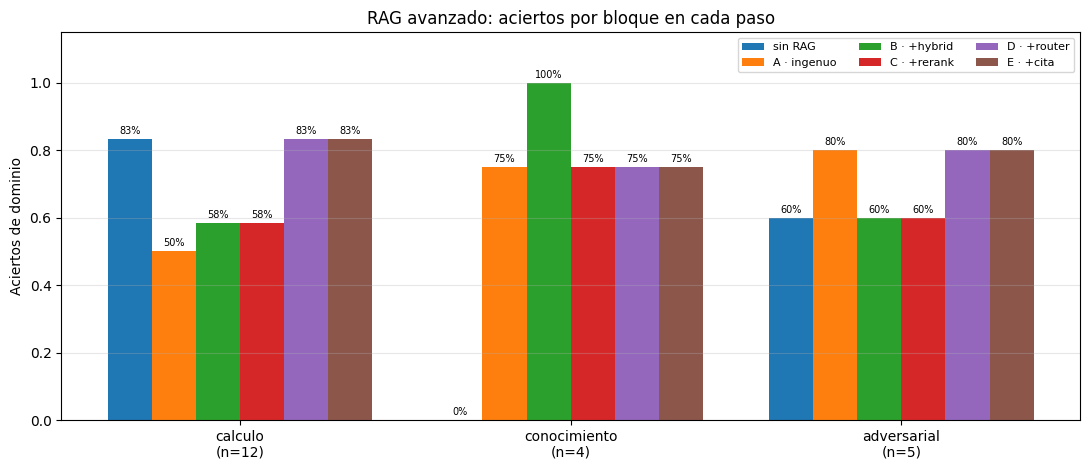

In [34]:
import matplotlib.pyplot as plt

bloques = [("calculo", "n_calculo", "aciertos_calculo"),
           ("conocimiento", "n_conocimiento", "aciertos_conocimiento"),
           ("adversarial", "n_adversarial", "aciertos_adversarial")]
x = np.arange(len(bloques)); ancho = 0.8 / len(nombres)
fig, ax = plt.subplots(figsize=(11, 4.8))
for j, nombre in enumerate(nombres):
    sc = scorecards[nombre]
    vals = [sc[a] / sc[n] for _, n, a in bloques]
    pos = x - 0.4 + ancho / 2 + j * ancho
    ax.bar(pos, vals, ancho, label=nombre)
    for p_, v in zip(pos, vals):
        ax.text(p_, v + 0.015, f"{v:.0%}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([f"{b}\n(n={scorecards[nombres[0]][n]})" for b, n, _ in bloques])
ax.set_ylim(0, 1.15); ax.set_ylabel("Aciertos de dominio")
ax.set_title("RAG avanzado: aciertos por bloque en cada paso")
ax.legend(ncol=3, fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

In [35]:
tabla_por_subtipo(*[scorecards[n] for n in nombres])

caso      subtipo                           sin RAG  A · ingenuo  B · +hybrid  C · +rerank  D · +router    E · +cita
-------------------------------------------------------------------------------------------------------------------
dif-01    multipaso_encadenado                   OK        FALLA        FALLA           OK           OK           OK
dif-02    informacion_distractora                OK        FALLA           OK           OK           OK           OK
dif-03    conversion_unidades                    OK           OK           OK           OK           OK           OK
dif-04    redondeo_contextual                    OK           OK        FALLA        FALLA           OK           OK
dif-05    division_decimal                       OK           OK           OK           OK           OK           OK
dif-06    porcentaje_encadenado                  OK        FALLA        FALLA        FALLA           OK           OK
dif-07    fraccion_del_resto                  FALLA        FALLA 

### 13.5 · Qué arregló y qué rompió cada paso

In [36]:
# Qué casos cambió cada paso. Es el diagnóstico que S07 no pudo hacer (§6.4).
for x, y in zip(nombres, nombres[1:]):
    cambios = [(a, b) for a, b in zip(scorecards[x]["detalle"], scorecards[y]["detalle"])
               if a["acierto"] != b["acierto"]]
    print(f"{x} -> {y}: {len(cambios)} cambio(s)")
    for a, b in cambios:
        flecha = "ARREGLÓ " if b["acierto"] else "ROMPIÓ  "
        print(f"   {flecha} {a['id']:8s} {a['subtipo']:26s} {b['motivo'][:44]}")

sin RAG -> A · ingenuo: 10 cambio(s)
   ROMPIÓ   dif-01   multipaso_encadenado       esperaba 45000, dio 1.43
   ROMPIÓ   dif-02   informacion_distractora    esperaba 96, dio 72
   ROMPIÓ   dif-06   porcentaje_encadenado      esperaba 144000, dio 200000
   ARREGLÓ  dif-10   porcentaje_inverso         número correcto
   ROMPIÓ   dif-11   promedio_ponderado         esperaba 3.71, dio 2.555
   ROMPIÓ   dif-12   probabilidad_sin_reemplazo esperaba 5/14, dio 5/8
   ARREGLÓ  con-01   politica_evaluacion        número correcto
   ARREGLÓ  con-03   nota_minima                contiene '3.0'
   ARREGLÓ  con-04   protocolo_pedagogico       contiene 'factor'
   ARREGLÓ  adv-04   fuera_de_dominio           reconoció el límite
A · ingenuo -> B · +hybrid: 5 cambio(s)
   ARREGLÓ  dif-02   informacion_distractora    número correcto
   ROMPIÓ   dif-04   redondeo_contextual        esperaba 7, dio 8
   ARREGLÓ  dif-07   fraccion_del_resto         número correcto
   ARREGLÓ  con-02   plan_de_area          

### 13.6 · Las consultas fallidas de S07

In [37]:
# Las consultas que S07 dejó para hoy, caso por caso: qué retrieval llevó al
# prompt y qué respondió cada sistema.
ruta_fallidas = Path("resultados/consultas_fallidas_s08.json")
fallidas_s07 = (json.loads(ruta_fallidas.read_text(encoding="utf-8")) if ruta_fallidas.exists()
                else [{"id": i} for i in ("con-02", "adv-02")])

por_id = {n: {d["id"]: d for d in scorecards[n]["detalle"]} for n in nombres}
for f in fallidas_s07:
    caso = next(c for c in eval_set if c["id"] == f["id"])
    print("=" * 90)
    print(f"[{caso['id']} · {caso['subtipo']}]  {caso['input']}")
    for nombre in nombres:
        d = por_id[nombre][caso["id"]]
        t = TRAZA[(nombre, caso["input"])]
        marca = "OK  " if d["acierto"] else ("abst" if d["abstuvo"] else "MAL ")
        print(f"  {nombre:13s} {marca} top-k={t['top_k']}")
        print(f"  {'':13s}      {d['respuesta'][:110]!r}")

[con-02 · plan_de_area]  ¿En qué grado se introducen las ecuaciones de primer grado según el plan de área de matemáticas del colegio?
  sin RAG       MAL  top-k=[]
                     'Paso 1: Los planes de estudio en educación secundaria suelen dividir los temas entre los grados.\nPaso 2: En el'
  A · ingenuo   MAL  top-k=['siee_chunk0', 'plan_area_chunk0', 'plan_area_chunk1']
                     'Paso 1: Según el plan de área, en grado sexto se trabajan las operaciones con números naturales, la divisibili'
  B · +hybrid   OK   top-k=['plan_area_chunk0', 'siee_chunk0', 'plan_area_chunk1']
                     'Paso 1: Según el plan de área, en sexto se trabajan las operaciones con números naturales.\nPaso 2: En séptimo '
  C · +rerank   abst top-k=['plan_area_chunk0', 'plan_area_chunk1', 'siee_chunk0']
                     'Paso 1: Según el plan de área, en grado sexto se trabajan las operaciones con números naturales.\nPaso 2: No ha'
  D · +router   abst top-k=['plan_area_chunk0', 

---
## 14 · Artefactos de la entrega

| Archivo | Contenido |
|---|---|
| `resultados/deltas_s08.csv` | La tabla de deltas paso a paso con McNemar y coste (entregable de S08) |
| `resultados/scorecard_rag_avanzado.csv` | Scorecard de los seis sistemas |
| `resultados/detalle_rag_avanzado.csv` | Caso por caso, **todos** los sistemas, con ruta y top-k |
| `resultados/retrieval_s08.csv` | Retrieval aislado por consulta y retriever |
| `resultados/m3_rag_avanzado.json` | Configuración, retrieval, enrutador, scorecards y coste |

In [38]:
import csv

Path("resultados").mkdir(exist_ok=True)
lista_sc = [scorecards[n] for n in nombres]

# 1 · Scorecard completo de los seis sistemas (mismo formato que M2 y S07)
guardar_scorecard("resultados/scorecard_rag_avanzado.csv", *lista_sc)

# 2 · deltas_s08.csv: el entregable que pide S08 (insumo de S09 y de la entrega M3)
with open("resultados/deltas_s08.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["sistema", "anade", "aciertos", "calculo", "conocimiento", "adversarial",
                "alucinaciones", "abstenciones", "juez", "sim", "delta_aciertos",
                "mejora", "empeora", "p_mcnemar", "ms_retrieval", "tokens_prompt"])
    previo = None
    for nombre, _, desc in SISTEMAS:
        sc = scorecards[nombre]
        m, e, p = mcnemar_exacto(scorecards[previo], sc) if previo else ("", "", "")
        w.writerow([nombre, desc, f"{sc['aciertos']}/{sc['n']}",
                    f"{sc['aciertos_calculo']}/{sc['n_calculo']}",
                    f"{sc['aciertos_conocimiento']}/{sc['n_conocimiento']}",
                    f"{sc['aciertos_adversarial']}/{sc['n_adversarial']}",
                    sc["alucinaciones"], sc["abstenciones"], round(sc["juez_promedio"], 2),
                    round(sc["sim_embeddings"], 3),
                    "" if previo is None else sc["aciertos"] - scorecards[previo]["aciertos"],
                    m, e, "" if p == "" else round(p, 3),
                    round(coste[nombre]["ms_retrieval_mediana"], 1),
                    round(coste[nombre]["tokens_prompt_media"])])
        previo = nombre
print("Guardado: resultados/deltas_s08.csv")

# 3 · Detalle caso por caso de TODOS los sistemas, con la traza del retrieval
with open("resultados/detalle_rag_avanzado.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["sistema", "id", "bloque", "subtipo", "ruta", "top_k", "acierto", "abstuvo",
                "alucino", "juez", "sim", "motivo", "respuesta"])
    for nombre in nombres:
        for d in scorecards[nombre]["detalle"]:
            t = TRAZA[(nombre, d["input"])]
            w.writerow([nombre, d["id"], d["bloque"], d["subtipo"], t["ruta"], "|".join(t["top_k"]),
                        d["acierto"], d["abstuvo"], d["alucino"], d["juez"], d["sim"],
                        d["motivo"], d["respuesta"]])
print("Guardado: resultados/detalle_rag_avanzado.csv")

# 4 · Retrieval aislado
df_ret.to_csv("resultados/retrieval_s08.csv", index=False, encoding="utf-8")
print("Guardado: resultados/retrieval_s08.csv")

# 5 · Todo junto, para el notebook de comparación y la documentación
Path("resultados/m3_rag_avanzado.json").write_text(json.dumps({
    "config": {"chunk_size": CHUNK_SIZE, "overlap": OVERLAP, "k": K, "k_recuperar": K_RECUPERAR,
               "n_documentos": len(corpus), "n_chunks": len(chunks),
               "modelo_embeddings": "paraphrase-multilingual-MiniLM-L12-v2",
               "reranker": "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
               "fusion": "RRF (k=60)",
               "enrutador": "regresión logística [margen centroides, nº números, rerank máx.]",
               "generador": f"{MODELO_BASE} + LoRA (M1)"},
    "retrieval": json.loads(resumen_ret.reset_index().to_json(orient="records")),
    "enrutador": {"loo_dev": acc, "loo_dev_solo_centroides": acc_cent,
                  "n_dev": len(consultas_dev), "pesos": dict(zip(RASGOS, map(float, coef))),
                  "rutas_eval": rutas_eval},
    "sistemas": {n: {k: v for k, v in scorecards[n].items() if k != "detalle"} for n in nombres},
    "coste": coste,
}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Guardado: resultados/m3_rag_avanzado.json")

Guardado: resultados/scorecard_rag_avanzado.csv
Guardado: resultados/deltas_s08.csv
Guardado: resultados/detalle_rag_avanzado.csv
Guardado: resultados/retrieval_s08.csv
Guardado: resultados/m3_rag_avanzado.json


---
## 15 · Discusión

Las preguntas a responder con las tablas de arriba, en este orden:

**1. ¿El retrieval tenía margen?** (sección 9)
Si A ya tenía hit@3 alto, B y C no podían mover el scorecard y su delta ≈ 0 es
la confirmación esperada, no un fracaso. Reporten hit@1 y latencia: el reranker
puede ordenar mejor y aun así *no valer su coste* en este corpus.

**2. ¿El enrutador recuperó el cálculo?** (13.2, fila C → D)
Es la hipótesis central del notebook. Si el bloque de cálculo vuelve a ~10/12 y
el de conocimiento se mantiene, la arquitectura compuesta que S07 proponía queda
**demostrada** y no solo argumentada. Miren también los tokens de prompt (13.3):
el enrutador además abarata.

**3. ¿El prompt de cita arregló `con-02`?** (13.6, fila D → E)
Si sí, el fallo era de generación y lo arregló la técnica que ataca generación:
el diagnóstico de S07 queda validado. Si no, el límite es el tamaño del modelo
(1.5B), y eso va a la sección de limitaciones.

**4. ¿Qué pasó con los adversariales?**
Ninguno es una consulta institucional, así que el enrutador los manda por la vía
sin RAG y pierden la válvula de escape del prompt de S07. Si el bloque
adversarial baja de C a D, es el coste del enrutador y hay que reportarlo.

**5. Tamaño de muestra.**
21 casos. Las conclusiones se apoyan en la dirección, en los casos concretos que
cambian y en el retrieval aislado, no en los p-valores.

---

### Lo que se lleva la entrega M3

1. **≥2 técnicas avanzadas justificadas con su delta**: hybrid search, reranking
   y enrutamiento, cada una medida con el mismo harness.
2. **`deltas_s08.csv`** con coste y significancia.
3. **El diagnóstico cerrado de S07**: qué casos arregló y rompió cada técnica.

---
## 16 · Conclusiones de esta corrida

> Cifras corregidas con `scripts/recalcular_criterio.py`: la corrida usó la versión
> antigua del eval set (arriba se ve `SHA coincide: False`) y el caso `adv-02` se
> re-evaluó después sobre las respuestas ya generadas. Cambiaron 4 celdas, todas del
> bloque adversarial. Detalle en `resultados/correccion_adv02.md`.

| Sistema | Total | Cálculo | Conoc. | Advers. | Alucin. | Δ | McNemar |
|---|---|---|---|---|---|---|---|
| sin RAG | 14/21 | 10/12 | 0/4 | 4/5 | 7 | — | — |
| A · ingenuo | 14/21 | 6/12 | 3/4 | 5/5 | 7 | 0 | 5/5, p = 1.000 |
| B · +hybrid | 14/21 | 7/12 | **4/4** | 3/5 | 6 | 0 | 3/3, p = 1.000 |
| C · +rerank | 13/21 | 7/12 | 3/4 | 3/5 | 5 | −1 | 2/3, p = 1.000 |
| **D · +router** | **18/21** | **10/12** | 3/4 | 5/5 | **2** | **+5** | 7/2, p = 0.180 |
| E · +cita | 18/21 | 10/12 | 3/4 | 5/5 | 3 | 0 | 0/0, p = 1.000 |

**1 · El retrieval mejoró y no movió el scorecard.** hit@1 pasó de 0.722 a 0.889 y
hit@3 llegó a 1.000 con el reranker, pero A → B → C se mueve entre 13 y 14 de 21. Es
la predicción de la sección 1: con hit@3 ya en 0.944, no había margen. La mejora de
B es real y está **fuera** del scorecard: en consultas con siglas el hit@3 sube de
0.5 a 1.0, y ese estilo no aparece en el eval set.

**2 · El enrutador es lo único que paga.** 14 → 18 de 21, recuperando el cálculo de
6/12 a 10/12 sin perder conocimiento, y bajando las alucinaciones de 7 a 2. El
clasificador de tres señales dio 97.0% en leave-one-out (frente a 78.8% de solo
centroides) y 16/16 sobre el eval set, que no vio al ajustarse. La arquitectura
compuesta que proponía la documentación de M2/M3 queda demostrada, y con más margen
del previsto: se estimaban 17/21.

**3 · El prompt de cita textual no arregló `con-02`.** Delta exactamente 0: ningún
caso cambió. El fallo de generación no se corrige pidiendo cita literal; es un límite
del modelo de 1.5B. Además baja el formato válido del 95% al 76%, porque el prompt de
cita compite con el formato "Paso N".

**4 · El coste.** El reranker triplica la latencia de recuperación (13 → 43 ms) sin
contrapartida en el scorecard. El enrutador abarata: el prompt medio baja de 541 a
193 tokens, porque los problemas de cálculo dejan de llevar contexto.

**5 · El riesgo declarado no se materializó.** Se advirtió que los adversariales
perderían la válvula de escape al ir por la vía sin RAG; con el criterio corregido, D
y E obtienen 5/5 en ese bloque, el mejor de los seis sistemas.